# Notebook 02: Lake Tahoe Wildfire Clustering

**Obstacle-aware k-means on a compact lake**

This notebook applies obstacle-aware k-means to wildfires in the Lake Tahoe basin. The lake acts as a geographic barrier: standard k-means measures distance as straight-line Euclidean distance between $(x, y)$ coordinates, so it can produce clusters that span the water. Obstacle-aware k-means adds an arc-length parameter $s$ along the lake's shoreline as a clustering feature, giving the algorithm a measure of separation along the boundary in addition to straight-line distance between points.

We compare three clusterings: standard k-means as the baseline, obstacle-aware k-means at equal weights (the simplest form of the method, weighting straight-line and shoreline distance equally), and obstacle-aware k-means with the shoreline weight tuned to tighten the clusters along the shore. The distance formula and its weights are introduced where the first obstacle-aware clustering is run.

We test the method at two spatial scales:

- **Basin scale**: all 1,068 wildfires within the TRPA basin.
- **Near-shore scale**: the 296 fires within 1 km of the shoreline, roughly the nearest 27% of the data.

The basin test asks whether the obstacle parameter helps group fires along the shoreline when they're spread across the whole study area. The near-shore test asks how the method behaves when fires are more concentrated near the boundary.

This analysis clusters on spatial features (longitude, latitude, $s$). The attributes fire size and cause are kept in the cleaned dataset so we can check whether the resulting clusters happen to differ in their attribute composition.

## 1. Setup

In [1]:
import os
# Prevent sklearn/kmeans from spawning parallel threads on Windows
# (suppresses OpenMP warning)
os.environ['OMP_NUM_THREADS'] = '1'

# Suppress unnecessary warnings 
import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings('ignore', category=IntegrationWarning)
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='threadpoolctl')

# Standard packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

#For querying USGS Hydrography dataset
import requests

# Database access for the FPA FOD wildfire data
import sqlite3

# Reading the TRPA basin boundary (GeoJSON)
import json

# Caching utilities so expensive cells only run once
import pickle
from pathlib import Path

# For polygon operations 
from shapely.geometry import Polygon as ShapelyPolygon, Point

# sklearn baseline and feature scaling
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import SplineBoundary, ObstacleKMeans, attribute_separation

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
})

# Consistent cluster colors across all plots
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# --- Caching ---
cache_dir = Path('../data/cached')
cache_dir.mkdir(parents=True, exist_ok=True)


def cached_or_run(cache_path, compute_fn, force_rerun=False):
    """Load from cache if it exists, otherwise run compute_fn and save."""
    cache_path = Path(cache_path)
    if cache_path.exists() and not force_rerun:
        print(f'Loading cached: {cache_path.name}')
        with open(cache_path, 'rb') as f:
            return pickle.load(f)
    print(f'Computing (will cache to {cache_path.name})...')
    result = compute_fn()
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f)
    return result


# --- Helpers ---
def arc_length_span(s_values):
    """Calculate the arc-length span of a cluster on the loop [0, 1].

    Span is 1 minus the largest gap between consecutive sorted s-values,
    where the wraparound from 1 back to 0 also counts as a gap. Lower span
    means the cluster's fires are more tightly packed along the shoreline.
    """
    if len(s_values) <= 1:
        return 0.0
    sorted_s = np.sort(s_values)
    gaps = np.diff(sorted_s)
    wrap_gap = (1.0 - sorted_s[-1]) + sorted_s[0]
    largest_gap = max(gaps.max(), wrap_gap)
    return 1.0 - largest_gap


def map_labels_to_reference(labels, reference_labels, k):
    """Map cluster labels so they align with a reference labeling.

    For each new label, finds the reference label it overlaps with most.
    Greedy assignment ensures no two new labels map to the same reference.
    Used here to keep cluster colors consistent across plots and across
    different clustering methods on the same data.
    """
    overlap = np.zeros((k, k), dtype=int)
    for i in range(k):
        for j in range(k):
            overlap[i, j] = np.sum((labels == i) & (reference_labels == j))

    mapping = {}
    used = set()
    sort_order = np.argsort(-overlap.max(axis=1))
    for i in sort_order:
        for j in np.argsort(-overlap[i]):
            if j not in used:
                mapping[i] = j
                used.add(j)
                break
    return mapping

## 2. Querying the USGS National Hydrography Dataset for Lake Tahoe

The NHD's Waterbody (Small Scale) layer returns several features named Lake Tahoe; we take the largest, the lake itself (~497 sq km). We pull the polygon by GNIS name, requesting coordinates in WGS 84, and confirm the feature came back as expected before extracting its vertices in the next cell.

In [2]:
# USGS NHD Waterbody (Small Scale) layer
NHD_WATERBODY_URL = (
    "https://hydro.nationalmap.gov/arcgis/rest/services/nhd/MapServer/10/query"
)

params = {
    'where': "GNIS_NAME = 'Lake Tahoe'",
    'outFields': 'GNIS_NAME,AREASQKM,ELEVATION,REACHCODE', #attributes for check
    'returnGeometry': 'true',
    'outSR': 4326,                          # WGS 84 (lat/lon)
    'f': 'json',
}

response = requests.get(NHD_WATERBODY_URL, params=params)
response.raise_for_status()
data = response.json()

n_features = len(data['features'])
print(f'Features returned: {n_features}')

for feat in data['features']:
    attrs = feat['attributes']
    print(f"  Name:       {attrs['GNIS_NAME']}")
    print(f"  Area:       {attrs['AREASQKM']:.1f} sq km")
    print(f"  Elevation:  {attrs['ELEVATION']:.0f} m")
    print(f"  Reach Code: {attrs['REACHCODE']}")

Features returned: 6
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 02080203002790
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03090206073133
  Name:       Lake Tahoe
  Area:       0.1 sq km
  Elevation:  0 m
  Reach Code: 03130005004183
  Name:       Lake Tahoe
  Area:       0.0 sq km
  Elevation:  0 m
  Reach Code: 06010105002593
  Name:       Lake Tahoe
  Area:       0.2 sq km
  Elevation:  0 m
  Reach Code: 07050002001323
  Name:       Lake Tahoe
  Area:       496.9 sq km
  Elevation:  1899 m
  Reach Code: 16050101000339


### Extracting Boundary Coordinates

The geometry is nested as `feature -> geometry -> rings -> [[lon, lat], ...]`. Multiple features came back, so we take the largest by area; if a single feature has multiple rings, we use the longest ring as the exterior boundary.

In [3]:
# Pick the largest feature if there are multiple
if n_features > 1:
    feat = max(data['features'], key=lambda f: f['attributes']['AREASQKM'])
    print(f"Multiple features found -- using the largest "
          f"({feat['attributes']['AREASQKM']:.1f} sq km)")
else:
    feat = data['features'][0]

rings = feat['geometry']['rings']
print(f'Number of rings: {len(rings)}')
for i, ring in enumerate(rings):
    print(f'  Ring {i}: {len(ring)} vertices')

# Use the longest ring as the exterior boundary
exterior_ring = max(rings, key=len)
coords = np.array(exterior_ring)
lon = coords[:, 0]
lat = coords[:, 1]

print(f'\nExterior ring: {len(lon)} vertices')
print(f'Longitude range: [{lon.min():.4f}, {lon.max():.4f}]')
print(f'Latitude range:  [{lat.min():.4f}, {lat.max():.4f}]')

is_closed = np.allclose(coords[0], coords[-1])
print(f'Ring is closed: {is_closed}')

Multiple features found -- using the largest (496.9 sq km)
Number of rings: 2
  Ring 0: 1528 vertices
  Ring 1: 11 vertices

Exterior ring: 1528 vertices
Longitude range: [-120.1635, -119.9262]
Latitude range:  [38.9286, 39.2489]
Ring is closed: True


### Visualizing the Raw Boundary

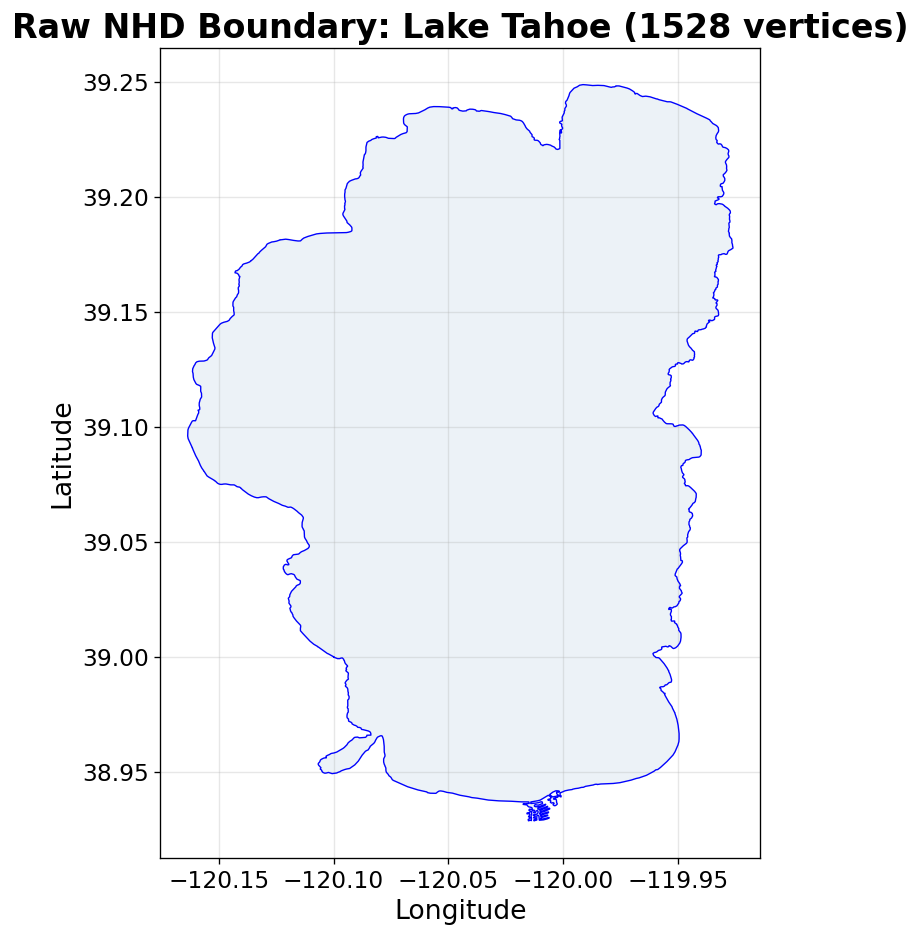

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lon, lat, 'b-', linewidth=0.8)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Raw NHD Boundary: Lake Tahoe ({len(lon)} vertices)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Cleaning the Boundary

Two cleanup steps:

1. **Remove the Tahoe Keys**: a marina with channels in the southwest corner of the lake. The NHD polygon traces every channel, which adds detail the cluster boundary doesn't need.
2. **Simplify the remaining shape**: apply Douglas-Peucker simplification with tolerance ~0.0005 degrees (~100 m) to reduce vertex count without losing the lake's geometry.

Tahoe Keys vertices identified: 246
Vertices after clipping: 1282 (removed 246)
Vertices after simplification: 269


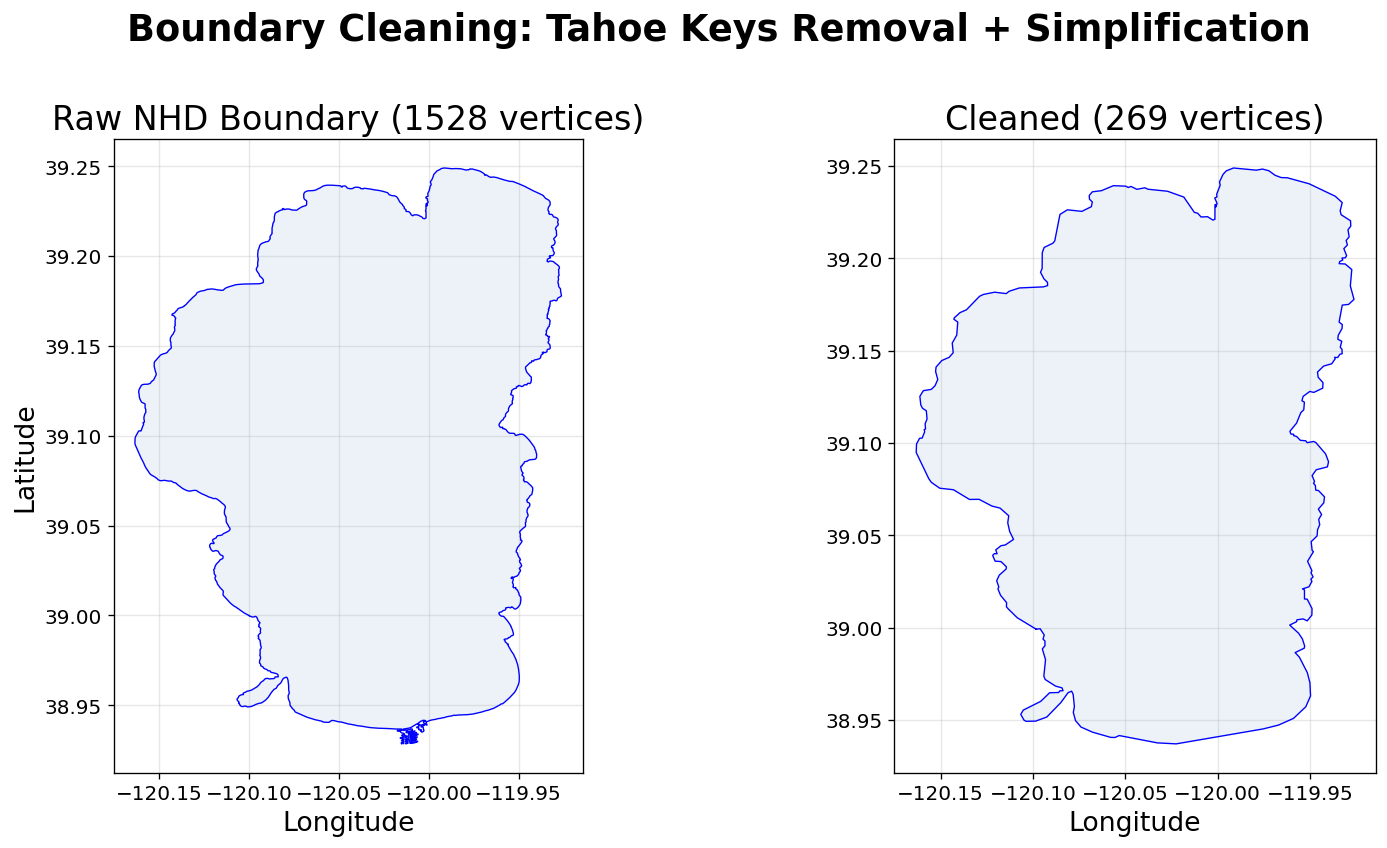


Using cleaned boundary downstream (269 vertices).


In [5]:
# --- Step 1: Remove the Tahoe Keys ---
# The Keys sit in the southern portion of the lake, roughly:
#   latitude < 38.945 and longitude > -120.02
# We drop any vertices inside this box and reconnect the survivors.
keys_mask = (lat < 38.945) & (lon > -120.02)
n_keys = int(np.sum(keys_mask))
print(f'Tahoe Keys vertices identified: {n_keys}')

lon_clipped = lon[~keys_mask]
lat_clipped = lat[~keys_mask]
print(f'Vertices after clipping: {len(lon_clipped)} (removed {n_keys})')

# --- Step 2: Simplify the remaining shape ---
clipped_polygon = ShapelyPolygon(list(zip(lon_clipped, lat_clipped)))
tolerance = 0.0005  # ~100 m at this latitude
simplified = clipped_polygon.simplify(tolerance, preserve_topology=True)

simple_coords = np.array(simplified.exterior.coords)
lon_simple = simple_coords[:, 0]
lat_simple = simple_coords[:, 1]

print(f'Vertices after simplification: {len(lon_simple)}')

# --- Before / After ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.plot(lon, lat, 'b-', linewidth=0.8)
ax.fill(lon, lat, alpha=0.1, color='steelblue')
ax.set_title(f'Raw NHD Boundary ({len(lon)} vertices)', fontweight='normal')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
ax.tick_params(axis='both', labelsize=12)  
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(lon_simple, lat_simple, 'b-', linewidth=0.8)
ax.fill(lon_simple, lat_simple, alpha=0.1, color='steelblue')
ax.set_title(f'Cleaned ({len(lon_simple)} vertices)', fontweight='normal')
ax.set_xlabel('Longitude')
ax.set_aspect('equal')
ax.tick_params(axis='both', labelsize=12)  
ax.grid(True, alpha=0.3)

plt.suptitle('Boundary Cleaning: Tahoe Keys Removal + Simplification', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# Replace lon/lat for all future cells
lon = lon_simple
lat = lat_simple
print(f'\nUsing cleaned boundary downstream ({len(lon)} vertices).')

### Saving Boundary Coordinates

In [6]:
boundary_dir = Path('../data/boundaries')
boundary_dir.mkdir(parents=True, exist_ok=True)
boundary_path = boundary_dir / 'tahoe_boundary.csv'

boundary_df = pd.DataFrame({'longitude': lon, 'latitude': lat})
boundary_df.to_csv(boundary_path, index=False)

print(f'Saved {len(boundary_df)} boundary points to {boundary_path}')

Saved 269 boundary points to ..\data\boundaries\tahoe_boundary.csv


## 4. Fitting the Spline Boundary

The `SplineBoundary` class fits a closed cubic spline through the boundary vertices. The spline gives a smooth, continuously differentiable representation of the shoreline parameterized by $t \in [0, 1]$. For each fire we'll later compute the closest point on this spline and record both its spline parameter $t$ and its arc-length position $s \in [0, 1]$. 

Total arc length: 1.2027 degrees (118.3 km)
Parameter range: (0.0, 1.0)

Start point (t=0): (-120.0983, 38.9991)
End point (t=1):   (-120.0983, 38.9991)
Start matches end: True


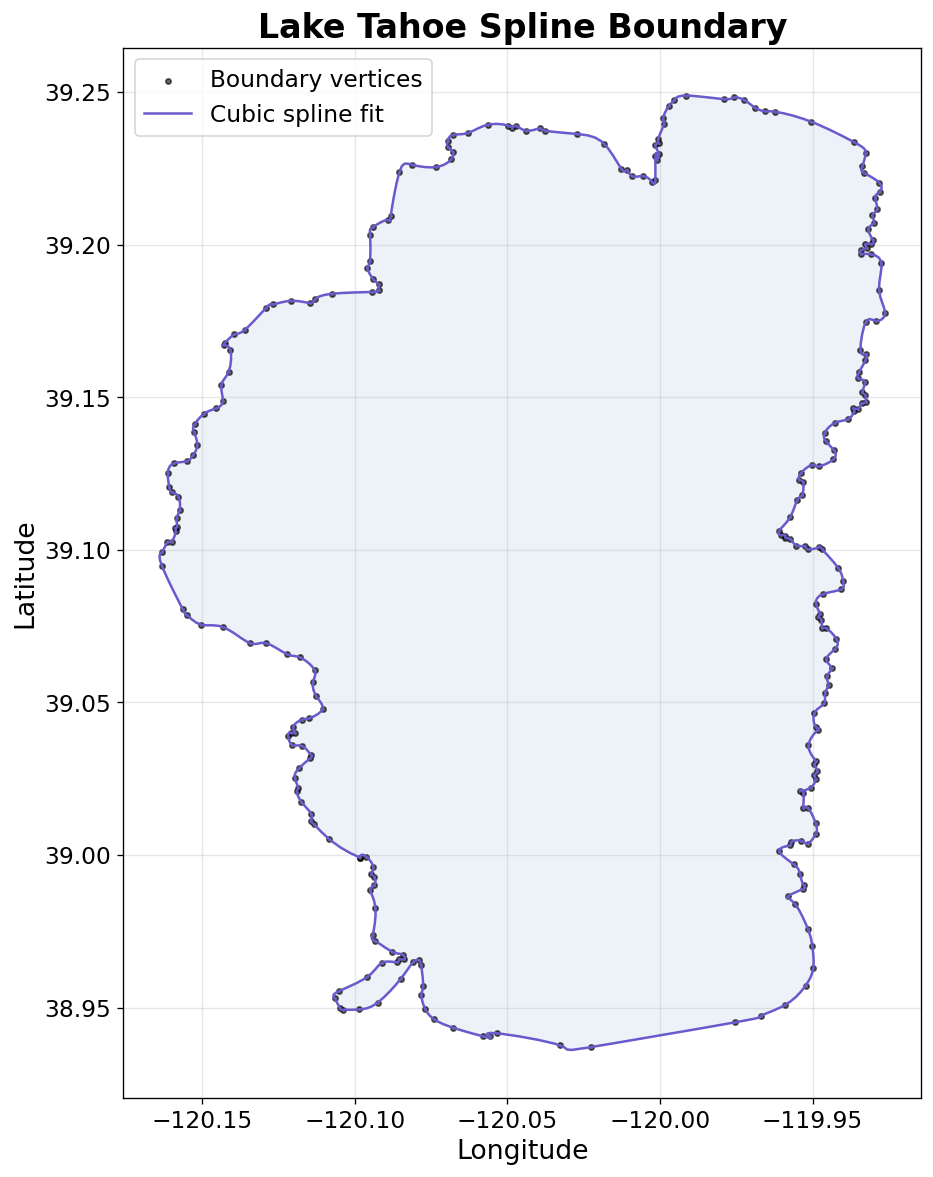

In [7]:
boundary = SplineBoundary(x_coords=lon, y_coords=lat)

L = boundary.total_arc_length()
# Convert total arc length to km using a local flat-earth approximation
# at this latitude. 1° latitude ≈ 111 km everywhere; 1° longitude ≈ 111 × cos(lat) km.
spline_dense = boundary.sample_boundary(n_points=5000)
lats_rad = np.deg2rad(spline_dense[:, 1])
dlon = np.diff(spline_dense[:, 0])
dlat = np.diff(spline_dense[:, 1])
mean_lat = 0.5 * (lats_rad[:-1] + lats_rad[1:])
seg_km = np.sqrt((dlat * 111)**2 + (dlon * 111 * np.cos(mean_lat))**2)
perimeter_km = seg_km.sum()
print(f'Total arc length: {L:.4f} degrees ({perimeter_km:.1f} km)')
print(f'Parameter range: {boundary.t_range()}')

# Verify start and end match (closed loop)
start_pt = boundary.evaluate(0.0)
end_pt = boundary.evaluate(1.0)
print(f'\nStart point (t=0): ({start_pt[0]:.4f}, {start_pt[1]:.4f})')
print(f'End point (t=1):   ({end_pt[0]:.4f}, {end_pt[1]:.4f})')
print(f'Start matches end: {np.allclose(start_pt, end_pt, atol=1e-3)}')

# Sample the spline for visualization
spline_pts = boundary.sample_boundary(n_points=1000)

fig, ax = plt.subplots(figsize=(8, 10))
ax.scatter(lon, lat, c='black', s=10, alpha=0.6, zorder=2, label='Boundary vertices')
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='slateblue', linewidth=1.5,
        zorder=3, label='Cubic spline fit')
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Lake Tahoe Spline Boundary')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Loading Wildfire Data

We pull wildfires from the FPA FOD SQLite database (the USDA Forest Service's Fire Program Analysis Fire-Occurrence Database, a record of US wildfires from 1992 to 2020) within a generous bounding box, then filter to fires inside the TRPA basin polygon (the official boundary of the Tahoe basin used for regulatory and ecological purposes).

The TRPA boundary file should be downloaded from <https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about> and placed at `data/raw/trpa_boundary.geojson`.

In [8]:
# --- Load the TRPA basin boundary ---
basin_path = Path('../data/raw/trpa_boundary.geojson')
if not basin_path.exists():
    raise FileNotFoundError(
        f'{basin_path} not found. Download the TRPA Boundary GeoJSON from\n'
        f'https://www.tahoeopendata.org/datasets/TRPA::trpa-boundary/about\n'
        f'and place it at this path.'
    )

with open(basin_path) as f:
    basin_geojson = json.load(f)

basin_coords = basin_geojson['features'][0]['geometry']['coordinates'][0]
basin_polygon = ShapelyPolygon(basin_coords)
print(f'TRPA basin: {len(basin_coords)} vertices')

# --- Query FPA FOD for fires in a bounding box around the basin ---
db_path = '../data/raw/fires.sqlite'

query = """
    SELECT LATITUDE, LONGITUDE, FIRE_SIZE, NWCG_GENERAL_CAUSE,
           NWCG_CAUSE_CLASSIFICATION, FIRE_YEAR, DISCOVERY_DOY
    FROM Fires
    WHERE LATITUDE BETWEEN 38.85 AND 39.35
      AND LONGITUDE BETWEEN -120.25 AND -119.85
"""

with sqlite3.connect(db_path) as conn:
    fires_raw = pd.read_sql_query(query, conn)

# --- Filter to fires inside the TRPA basin polygon ---
fires_raw['_pt'] = fires_raw.apply(
    lambda row: Point(row['LONGITUDE'], row['LATITUDE']), axis=1
)
fires_raw['in_basin'] = fires_raw['_pt'].apply(basin_polygon.contains)

n_before = len(fires_raw)
fires_raw = fires_raw[fires_raw['in_basin']].drop(columns=['_pt', 'in_basin']).copy()
n_after = len(fires_raw)

print(f'Fires in SQL bounding box: {n_before}')
print(f'Fires within TRPA basin:   {n_after}')
print(f'Year range: {fires_raw["FIRE_YEAR"].min()}-{fires_raw["FIRE_YEAR"].max()}')
print(f'\nCause breakdown:')
print(fires_raw['NWCG_GENERAL_CAUSE'].value_counts().to_string())

TRPA basin: 3387 vertices
Fires in SQL bounding box: 1888
Fires within TRPA basin:   1376
Year range: 1992-2020

Cause breakdown:
NWCG_GENERAL_CAUSE
Recreation and ceremony                       391
Missing data/not specified/undetermined       308
Natural                                       204
Smoking                                       166
Arson/incendiarism                             85
Misuse of fire by a minor                      71
Debris and open burning                        65
Equipment and vehicle use                      36
Power generation/transmission/distribution     35
Fireworks                                      10
Other causes                                    5


## 6. Cleaning and Feature Engineering

Three steps:

1. **Drop fires with missing or undetermined cause**. This isn't required for spatial clustering, but it keeps the row set consistent with the cause exploration in section 17.
2. **Encode cause as a binary** (0 = Natural / lightning, 1 = Human-caused). We carry this and the raw fire size on the cleaned data, used for attribute exploration in section 17.
3. **Log-transform fire size**, since the raw distribution is heavily right-skewed (median ~0.1 acres, max in the thousands).

In [9]:
# --- Step 1: Filter out missing/undetermined cause ---
fires = fires_raw[
    fires_raw['NWCG_GENERAL_CAUSE'] != 'Missing data/not specified/undetermined'
].copy().reset_index(drop=True)

print(f'Fires after filtering missing cause: {len(fires)}')

# --- Step 2: Encode cause as binary ---
# 0 = Natural, 1 = Human-caused
fires['cause_binary'] = (fires['NWCG_GENERAL_CAUSE'] != 'Natural').astype(int)


# --- Step 3: Log-transform fire size ---
# Heavy right tail
fires['fire_size_log'] = np.log1p(fires['FIRE_SIZE'].values)

print(f'\nCause classification:')
print(f"  Natural (lightning): {(fires['cause_binary'] == 0).sum()}")
print(f"  Human-caused:        {(fires['cause_binary'] == 1).sum()}")

print(f'\nFire size (acres):')
print(f"  Min:    {fires['FIRE_SIZE'].min():.4f}")
print(f"  Median: {fires['FIRE_SIZE'].median():.2f}")
print(f"  Mean:   {fires['FIRE_SIZE'].mean():.2f}")
print(f"  Max:    {fires['FIRE_SIZE'].max():.2f}")

Fires after filtering missing cause: 1068

Cause classification:
  Natural (lightning): 204
  Human-caused:        864

Fire size (acres):
  Min:    0.0100
  Median: 0.10
  Mean:   10.39
  Max:    4222.00


## 7. Projecting Fires onto the Lake Boundary

For each fire we find the point on the boundary spline closest to it. The result gives us two values per fire:

- $t$ (spline parameter): used internally by `ObstacleKMeans` to evaluate boundary positions during distance calculations.
- $s$ (arc-length parameter, normalized to $[0, 1]$): the clustering feature itself, and the basis for the per-cluster arc-length span metric. It's derived from $t$ but spaced by true distance along the shore, so equal steps in $s$ cover equal stretches of shoreline.

First run can take a few minutes. The result is cached, so reruns are fast.

In [10]:
def project_all_fires():
    print('Projecting fire locations onto lake boundary...')
    lons = fires['LONGITUDE'].values
    lats = fires['LATITUDE'].values
    n = len(fires)

    t_arr = np.zeros(n)
    s_arr = np.zeros(n)
    for idx in range(n):
        if idx % 200 == 0:
            print(f'  {idx}/{n} ({100*idx/n:.0f}%)')
        t_arr[idx], s_arr[idx] = boundary.project_point(lons[idx], lats[idx])
    return t_arr, s_arr


t_values, s_values = cached_or_run(
    cache_dir / 'tahoe_fire_projections.pkl',
    project_all_fires,
)

fires['t_param'] = t_values
fires['s_param'] = s_values

print(f'Projection complete: {len(fires)} fires projected')
print(f's range: [{fires["s_param"].min():.4f}, {fires["s_param"].max():.4f}]')

Loading cached: tahoe_fire_projections.pkl
Projection complete: 1068 fires projected
s range: [0.0069, 0.9980]


### Visualizing the Raw Data

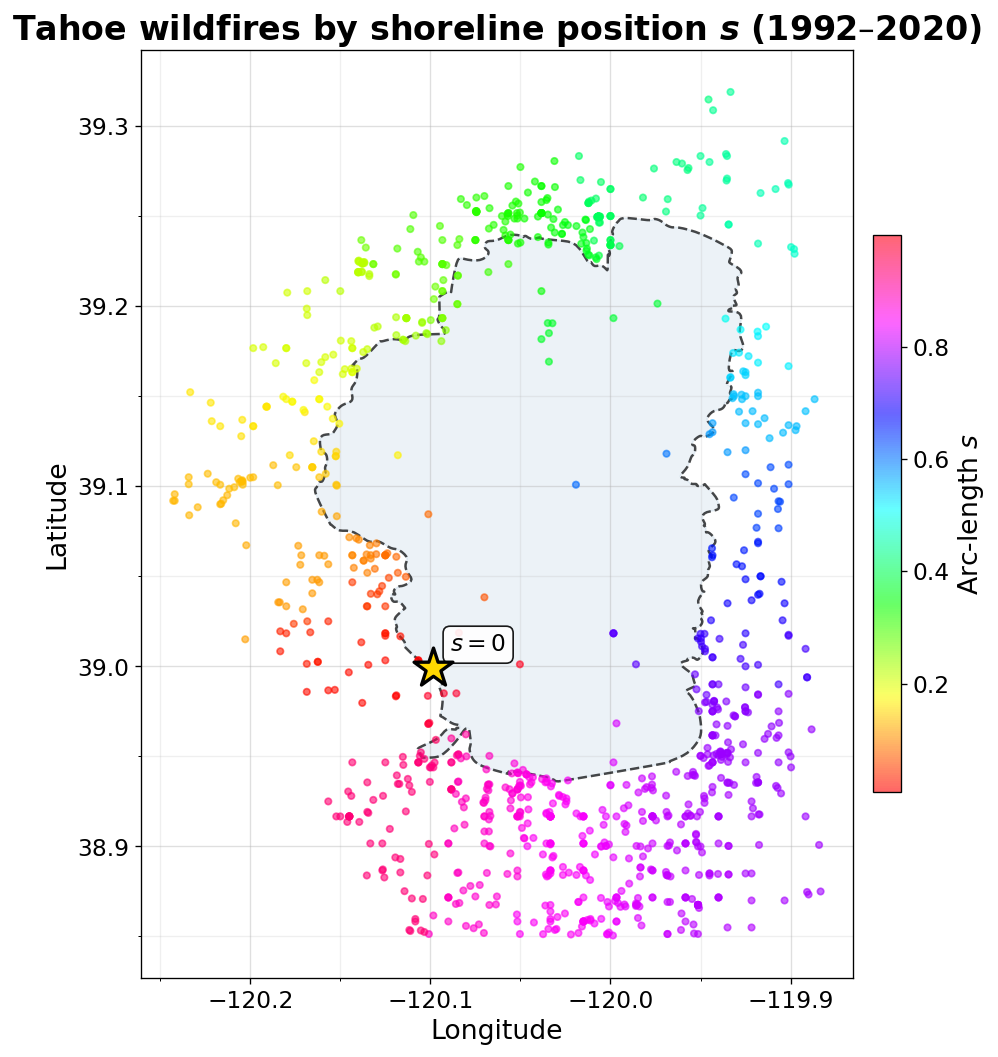

In [11]:
fig, ax = plt.subplots(figsize=(9, 9))

# Boundary
ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
        linewidth=1.5, alpha=0.7)
ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.1, color='steelblue')

# Fires colored by arc-length position. HSV wraps, so s=0 and s=1 share a color.
scatter = ax.scatter(fires['LONGITUDE'], fires['LATITUDE'],
                     c=fires['s_param'], cmap='hsv', s=15, alpha=0.6, zorder=3)
plt.colorbar(scatter, ax=ax, label='Arc-length $s$', shrink=0.6, aspect=20, pad=0.02)

# Mark the boundary's start position (s = 0)
s0_xy = boundary.evaluate(boundary.t_range()[0])
ax.scatter(s0_xy[0], s0_xy[1], marker='*', s=600, color='gold',
           edgecolors='black', linewidth=2, zorder=10)
ax.annotate('$s = 0$', xy=(s0_xy[0], s0_xy[1]), xytext=(10, 10),
            textcoords='offset points', fontsize=14, fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', edgecolor='black',
                      boxstyle='round,pad=0.3', alpha=0.9))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')

# Gridlines every 0.05 on both axes; labels only every 0.10
ax.xaxis.set_major_locator(MultipleLocator(0.10))   # labeled
ax.xaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
ax.yaxis.set_major_locator(MultipleLocator(0.10))   # labeled
ax.yaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
ax.grid(which='major', alpha=0.4)
ax.grid(which='minor', alpha=0.2)

year_min = fires['FIRE_YEAR'].min()
year_max = fires['FIRE_YEAR'].max()
ax.set_title(r"Tahoe wildfires by shoreline position $\boldsymbol{s}$ "
             f'({year_min}\u2013{year_max})')

plt.tight_layout()
plt.show()

## 8. Feature Matrix

The full feature matrix has five columns:

- Columns 0, 1: scaled longitude and latitude (Min-Max to $[0, 1]$)
- Column 2: arc-length parameter $s$ (already in $[0, 1]$)
- Column 3: log-transformed fire size, Min-Max scaled
- Column 4: cause binary (0 or 1)

The clustering uses only the first three columns, the spatial features. Fire size and cause are kept in the matrix but left out of the clustering objective; we look at them separately in section 17.

In [12]:
# Geographic coordinates: Min-Max scale to [0, 1]
scaler_xy = MinMaxScaler()
xy_scaled = scaler_xy.fit_transform(fires[['LONGITUDE', 'LATITUDE']].values)

# Fire size (log): Min-Max scale to [0, 1]
scaler_size = MinMaxScaler()
fire_size_scaled = scaler_size.fit_transform(fires[['fire_size_log']].values)

# Assemble the feature matrix
X = np.column_stack([
    xy_scaled,                          # columns 0, 1: scaled longitude, latitude
    fires['s_param'].values,            # column 2: arc-length parameter
    fire_size_scaled.ravel(),           # column 3: log-scaled fire size
    fires['cause_binary'].values        # column 4: cause type
])

feature_names = ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_names}')

Feature matrix shape: (1068, 5)
Features: ['x_scaled', 'y_scaled', 's', 'fire_size', 'cause_type']


## 9. Basin-Scale Clustering: Standard k-means Baseline

The first method is plain k-means on scaled $(x, y)$ only. We record its mean arc-length span; every obstacle-aware variant that follows is measured against this number.

Before clustering, we pick the number of clusters.

### Choosing the Number of Clusters (Elbow Method)

We use the elbow method to choose $k$. It runs k-means for a range of $k$ values and plots the inertia (within-cluster sum of squared distances) at each. A good $k$ is where the curve bends; adding more clusters beyond that point gives diminishing returns.

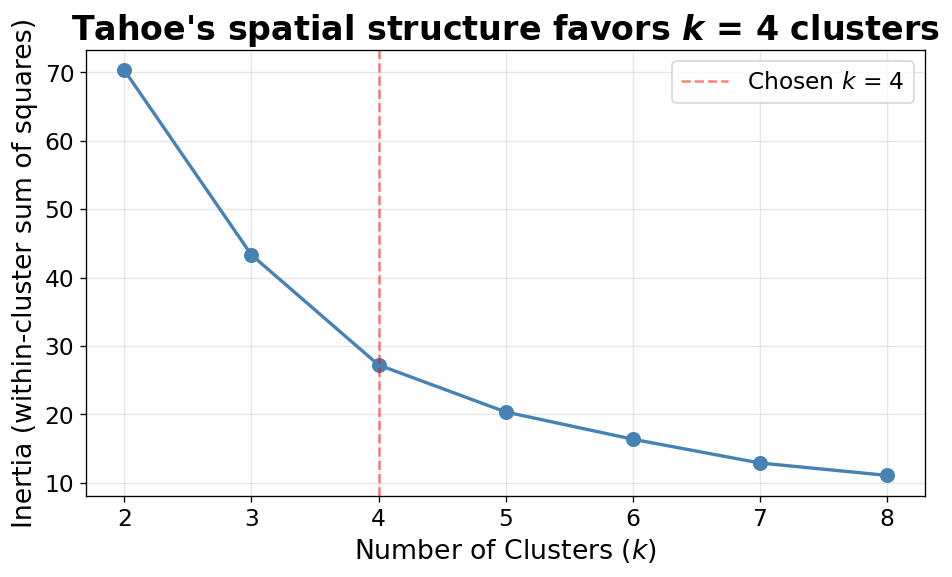

Inertia by k:
  k=2: 70.3290
  k=3: 43.3322
  k=4: 27.2352
  k=5: 20.3613
  k=6: 16.3810
  k=7: 12.9070
  k=8: 11.0922


In [13]:
# Elbow method: test k = 2 through 8
k_range = range(2, 9)
inertias = []

for k_test in k_range:
    km = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km.fit(xy_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)

# Mark the chosen k
ax.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='Chosen $k$ = 4')

ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title(r"Tahoe's spatial structure favors $\boldsymbol{k}$ = 4 clusters")
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the values for reference
print('Inertia by k:')
for k_test, inertia in zip(k_range, inertias):
    print(f'  k={k_test}: {inertia:.4f}')

The inertia curve flattens noticeably after $k = 4$, suggesting four clusters fit the spatial structure well. We use $k = 4$ throughout the rest of the notebook.

### Running the Clustering

We cluster with standard k-means, then calculate each cluster's arc-length span: the shortest stretch of shoreline containing all its fires, as a fraction of the full loop. Then report the mean across the four clusters. This mean arc-length span is the baseline the obstacle-aware variants are compared against.

In [14]:
k = 4 # from the elbow plot above

# Standard k-means on scaled (x, y) only
kmeans_basin = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_basin_std = kmeans_basin.fit_predict(X[:, :2])

# Per-cluster arc-length span, then averaged below for the baseline number
spans_basin_std = [
    arc_length_span(fires['s_param'].values[labels_basin_std == c])
    for c in range(k)
]

print(f'Standard k-means converged in {kmeans_basin.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_std == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_std):.4f}')
print(f'\nSee clusters plotted in Section 12')

Standard k-means converged in 10 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 230 fires
  Cluster 3: 223 fires
  Cluster 4: 310 fires

Mean arc-length span: 0.2650

See clusters plotted in Section 12


## 10. Basin-Scale Clustering: Obstacle-Aware k-means at Equal Weights

Obstacle-aware k-means replaces the straight-line distance with a weighted combination of straight-line distance and distance along the shoreline. Each fire is a feature vector $\mathbf{x} = (\text{geo}, s)$, where $\text{geo} = (x, y)$ is its scaled coordinates and $s$ is its arc-length position along the shoreline. The distance between two fires $\mathbf{x} = (\text{geo}, s)$ and $\mathbf{x}' = (\text{geo}', s')$ is:

$$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \, \lVert \text{geo} - \text{geo}' \rVert^2 + \beta^2 \, d_s(s, s')^2$$

The first term is the usual straight-line distance between the scaled coordinates. The second is the distance between the two fires' positions along the shoreline, where $d_s$ measures the shorter way around the loop (so $s = 0.99$ and $s = 0.01$ are close, not far apart). The weight $\alpha$ cales the straight-line term, and $\beta$ scales the shoreline term. Because only the ratio between the weights matters, we hold $\alpha = 1$ throughout and vary $\beta$. Therefore, $\beta = 0$ recovers standard k-means, and larger $\beta$ gives the shoreline more say.

We start at equal weights, $\alpha = \beta = 1$: straight-line and shoreline distance contributing equally before any tuning.

In [15]:
# OA equal weights: pass the 3-column matrix (scaled x, y, s) plus t_data separately.
model_basin_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0, # gamma=0, n_attr=0: no attribute term, spatial features only for this project
    random_state=42, n_attr=0
)
model_basin_eq.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_eq = model_basin_eq.labels_

spans_basin_eq = [
    arc_length_span(fires['s_param'].values[labels_basin_eq == c])
    for c in range(k)
]

print(f'OA equal weights: converged in {model_basin_eq.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_eq == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_eq):.4f}')
print(f'\nSee clusters plotted in Section 12')

OA equal weights: converged in 13 iterations

Cluster sizes:
  Cluster 1: 305 fires
  Cluster 2: 236 fires
  Cluster 3: 216 fires
  Cluster 4: 311 fires

Mean arc-length span: 0.2475

See clusters plotted in Section 12


## 11. Basin-Scale Clustering: Obstacle-Aware k-means at Optimized $\beta$

Equal weights are a starting point, not necessarily the best choice. To tune $\beta$ we need a way to score a clustering, so we use an objective $J$ that measures within-cluster compactness. For a clustering with centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$:

$$J = \frac{1}{k} \sum_{c=1}^{k} \frac{1}{|C_c|} \sum_{i \in C_c} \left( \lVert \text{geo}_i - \text{geo}_{\mu_c} \rVert^2 + d_s(s_i, s_{\mu_c})^2 \right)$$

The inner sum averages each cluster's squared distances to its centroid, combining the straight-line part in scaled $(x, y)$ with the loop-aware part in $s$; the outer sum averages over the four clusters. Lower $J$ means tighter, more coherent clusters.

A key property is that $J$ is measured in fixed units, with no $\beta$ applied. That makes $J$ values comparable across $\beta$.

We sweep $\beta$ over a 30-point grid from 0.05 to 2.5, holding $\alpha = 1$. At each $\beta$ we record both $J$ and the mean arc-length span. The plot below puts the two on a shared $\beta$ axis so we can see how compactness and shoreline tightness move as $\beta$ changes.

First run can take several minutes. The result is cached, so reruns are fast.

In [ ]:
def compute_tahoe_basin_beta_sweep():
    """Sweep beta, recording J (within-cluster distortion) and mean span at each.

    One model fit per beta gives both metrics, so J and span always come from
    the same clustering rather than two separate fits.
    """
    print('Computing Tahoe basin beta sweep (J and span)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.5, n_grid)
    J_vals = np.zeros(n_grid)
    span_vals = np.zeros(n_grid)

    for i, b in enumerate(beta_vals):
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X[:, :3], t_data=fires['t_param'].values)

        # J is the model's mean within-cluster distortion (rho_bar):
        # geographic squared distance plus loop-aware s distance, averaged
        # over clusters. No beta is applied, so J is comparable across beta.
        J_vals[i] = model_b.rho_bar_

        # Mean arc-length span from the same fit
        spans_b = [
            arc_length_span(fires['s_param'].values[model_b.labels_ == c])
            for c in range(k)
        ]
        span_vals[i] = np.mean(spans_b)

    return beta_vals, J_vals, span_vals


beta_grid_basin, J_vals_basin, spans_by_beta_basin = cached_or_run(
    cache_dir / 'tahoe_basin_beta_sweep.pkl',
    compute_tahoe_basin_beta_sweep,
)

# Where J is lowest on the grid, for reference 
i_min_basin = J_vals_basin.argmin()
j_min_beta_basin = beta_grid_basin[i_min_basin]
j_min_J_basin = J_vals_basin[i_min_basin]

print(f'J-minimum on grid: beta = {j_min_beta_basin:.4f}, J = {j_min_J_basin:.4f}')

Loading cached: tahoe_basin_beta_sweep.pkl
J-minimum on grid: beta = 0.8103, J = 0.0307


### Selecting $\beta$ and Refitting

The sweep found the lowest $J$ at $\beta = 0.81$, but we can verify whether it is the best choice using the plot below. $J$ sits low in two separate basins with a ridge between them, and the two are nearly tied in objective value. Since $J$ doesn't single one out, we break the tie with the span: the basin near $\beta \approx 2.0$ reaches the lowest mean span on the plot. To make the choice robust, we restrict to swept $\beta$ values whose $J$ is within a small tolerance of the grid minimum and that sit in a stable low-$J$ stretch (at least one neighbor is also low-$J$, which rules out isolated single-point dips). We also require every cluster to hold more than 10 fires, which keeps out solutions where one cluster collapses onto a handful of points. Among the betas that pass, we take the one with the smallest span and refit there.

In [17]:
# Among betas within J_tol of the best J that sit in a stable low-J stretch
# (at least one neighbor also low-J), take the smallest span whose clustering
# has every cluster above the size floor n=10. We check candidates in span order
# and stop at the first that passes.
J_tol = 0.001
min_cluster_size = 10

# Require low J
J_best = J_vals_basin.min()
low_J = J_vals_basin <= J_best + J_tol

# Stable = at least one adjacent beta is also low-J
left_ok = np.zeros_like(low_J)
right_ok = np.zeros_like(low_J)
left_ok[1:] = low_J[:-1]
right_ok[:-1] = low_J[1:]
stable = low_J & (left_ok | right_ok)

# Stable candidate indices, ordered by increasing span 
candidates = np.where(stable)[0]
candidates = candidates[np.argsort(spans_by_beta_basin[candidates])]


# Check if candidates meet cluster size requirements
opt_beta_basin = None
for idx in candidates:
    b = beta_grid_basin[idx]
    m = ObstacleKMeans(k=k, boundary=boundary, alpha=1.0, beta=b, gamma=0.0,
                       random_state=42, n_attr=0)
    m.fit(X[:, :3], t_data=fires['t_param'].values)
    sizes = [np.sum(m.labels_ == c) for c in range(k)]
    if min(sizes) > min_cluster_size:
        opt_beta_basin = b
        i_sel = idx
        break

if opt_beta_basin is None:
    raise ValueError('No stable low-J beta satisfies the size floor; loosen J_tol.')

print(f'Selected beta = {opt_beta_basin:.4f} '
      f'(J = {J_vals_basin[i_sel]:.4f}, span = {spans_by_beta_basin[i_sel]:.4f})')

Selected beta = 1.9931 (J = 0.0308, span = 0.2435)


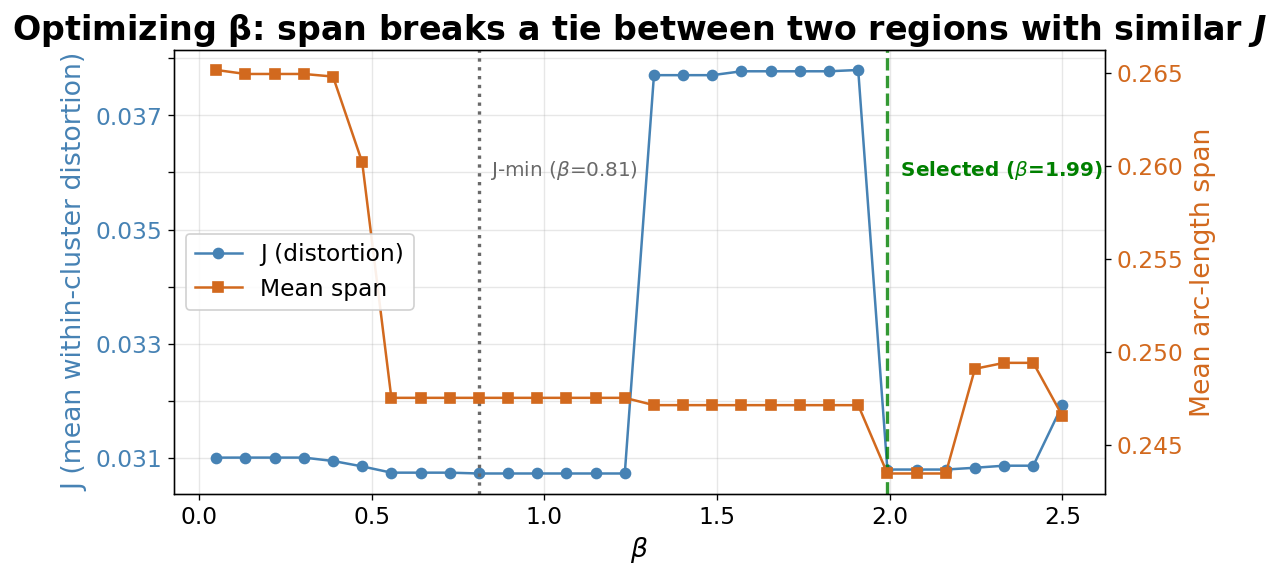

In [ ]:
# Plot the J / span over the 30 beta grid points
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: objective J (within-cluster distortion)
color_J = 'steelblue'
ax1.plot(beta_grid_basin, J_vals_basin, 'o-', color=color_J, label='J (distortion)')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J (mean within-cluster distortion)', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

# Gridlines every 0.001 on J axis, but label only every other one
ax1.yaxis.set_major_locator(MultipleLocator(0.001))
def label_every_other(x, pos):
    # Round to handle floating-point imprecision (0.032000000001 etc.)
    return f'{x:.3f}' if round(x * 1000) % 2 == 1 else ''
ax1.yaxis.set_major_formatter(FuncFormatter(label_every_other))

# Right axis: mean arc-length span
ax2 = ax1.twinx()
color_span = 'chocolate'  
ax2.plot(beta_grid_basin, spans_by_beta_basin, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

# Mark the J-minimum 
ax1.axvline(j_min_beta_basin, color='dimgray', linestyle=':', alpha=1.0, linewidth=2)
ax1.text(j_min_beta_basin, ax1.get_ylim()[1] * 0.95,
         rf'  J-min ($\beta$={j_min_beta_basin:.2f})',
         color='dimgray', fontsize=12, va='top', ha='left')

# Mark the selected beta (lower span among stable low-J region)
ax1.axvline(opt_beta_basin, color='green', linestyle='--', alpha=0.8, linewidth=2)
ax1.text(opt_beta_basin, ax1.get_ylim()[1] * 0.95,
         rf'  Selected ($\beta$={opt_beta_basin:.2f})',
         color='green', fontsize=12, va='top', ha='left', fontweight='bold')

ax1.set_title(r'Optimizing $\mathbf{\beta}$: span breaks a tie between two regions with similar $\boldsymbol{J}$')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes (just J and span, no vertical-line clutter)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc='center left')
leg.set_zorder(10)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

In [19]:
# Refit at the selected beta 
model_basin_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_basin, gamma=0.0,
    random_state=42, n_attr=0
)
model_basin_opt.fit(X[:, :3], t_data=fires['t_param'].values)
labels_basin_opt = model_basin_opt.labels_

spans_basin_opt = [
    arc_length_span(fires['s_param'].values[labels_basin_opt == c])
    for c in range(k)
]

print(f'Optimized beta: {opt_beta_basin:.4f}')
print(f'(J-minimum on grid was at beta = {j_min_beta_basin:.4f})')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_basin_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_basin_opt):.4f}')

Optimized beta: 1.9931
(J-minimum on grid was at beta = 0.8103)

Cluster sizes:
  Cluster 1: 307 fires
  Cluster 2: 236 fires
  Cluster 3: 311 fires
  Cluster 4: 214 fires

Mean arc-length span: 0.2435


## 12. Basin Clustering Method Comparison

We compare the results of our three clustering methods on the basin-wide dataset.

### Aligning Cluster Labels
Because k-means assigns cluster IDs arbitrarily, the same geographic group might be labeled "Cluster 1" in one run and "Cluster 3" in another. We use a greedy overlap-based mapping to relabel the obstacle-aware clusters so they share IDs (and therefore colors) with the standard k-means baseline. This is a visual aid only; it doesn't change the underlying clustering.

In [20]:
# Standard k-means is the reference labeling for the basin
labels_basin_std_aligned = labels_basin_std  # reference by definition

# Align equal-weight and optimized labels to the standard
eq_to_std_basin = map_labels_to_reference(labels_basin_eq, labels_basin_std, k)
labels_basin_eq_aligned = np.array(
    [eq_to_std_basin[l] for l in labels_basin_eq]
)

opt_to_std_basin = map_labels_to_reference(labels_basin_opt, labels_basin_std, k)
labels_basin_opt_aligned = np.array(
    [opt_to_std_basin[l] for l in labels_basin_opt]
)

print('Labels aligned: equal-weight and optimized clusters now share IDs')
print('with the standard k-means baseline.')

Labels aligned: equal-weight and optimized clusters now share IDs
with the standard k-means baseline.


### Visual Comparison

The same 1,068 fires clustered three ways: standard k-means, obstacle-aware at equal weights, and obstacle-aware at the optimized $\beta$. With shared colors from the label alignment, the three panels are directly comparable cluster by cluster.

The differences are subtle at this basin scale. The overall four-way split is stable across all three panels, so adding the shoreline parameter doesn't reorganize the clustering much. The only shift is a difference in cluster assignment among a handful of fires near the borders between clusters.

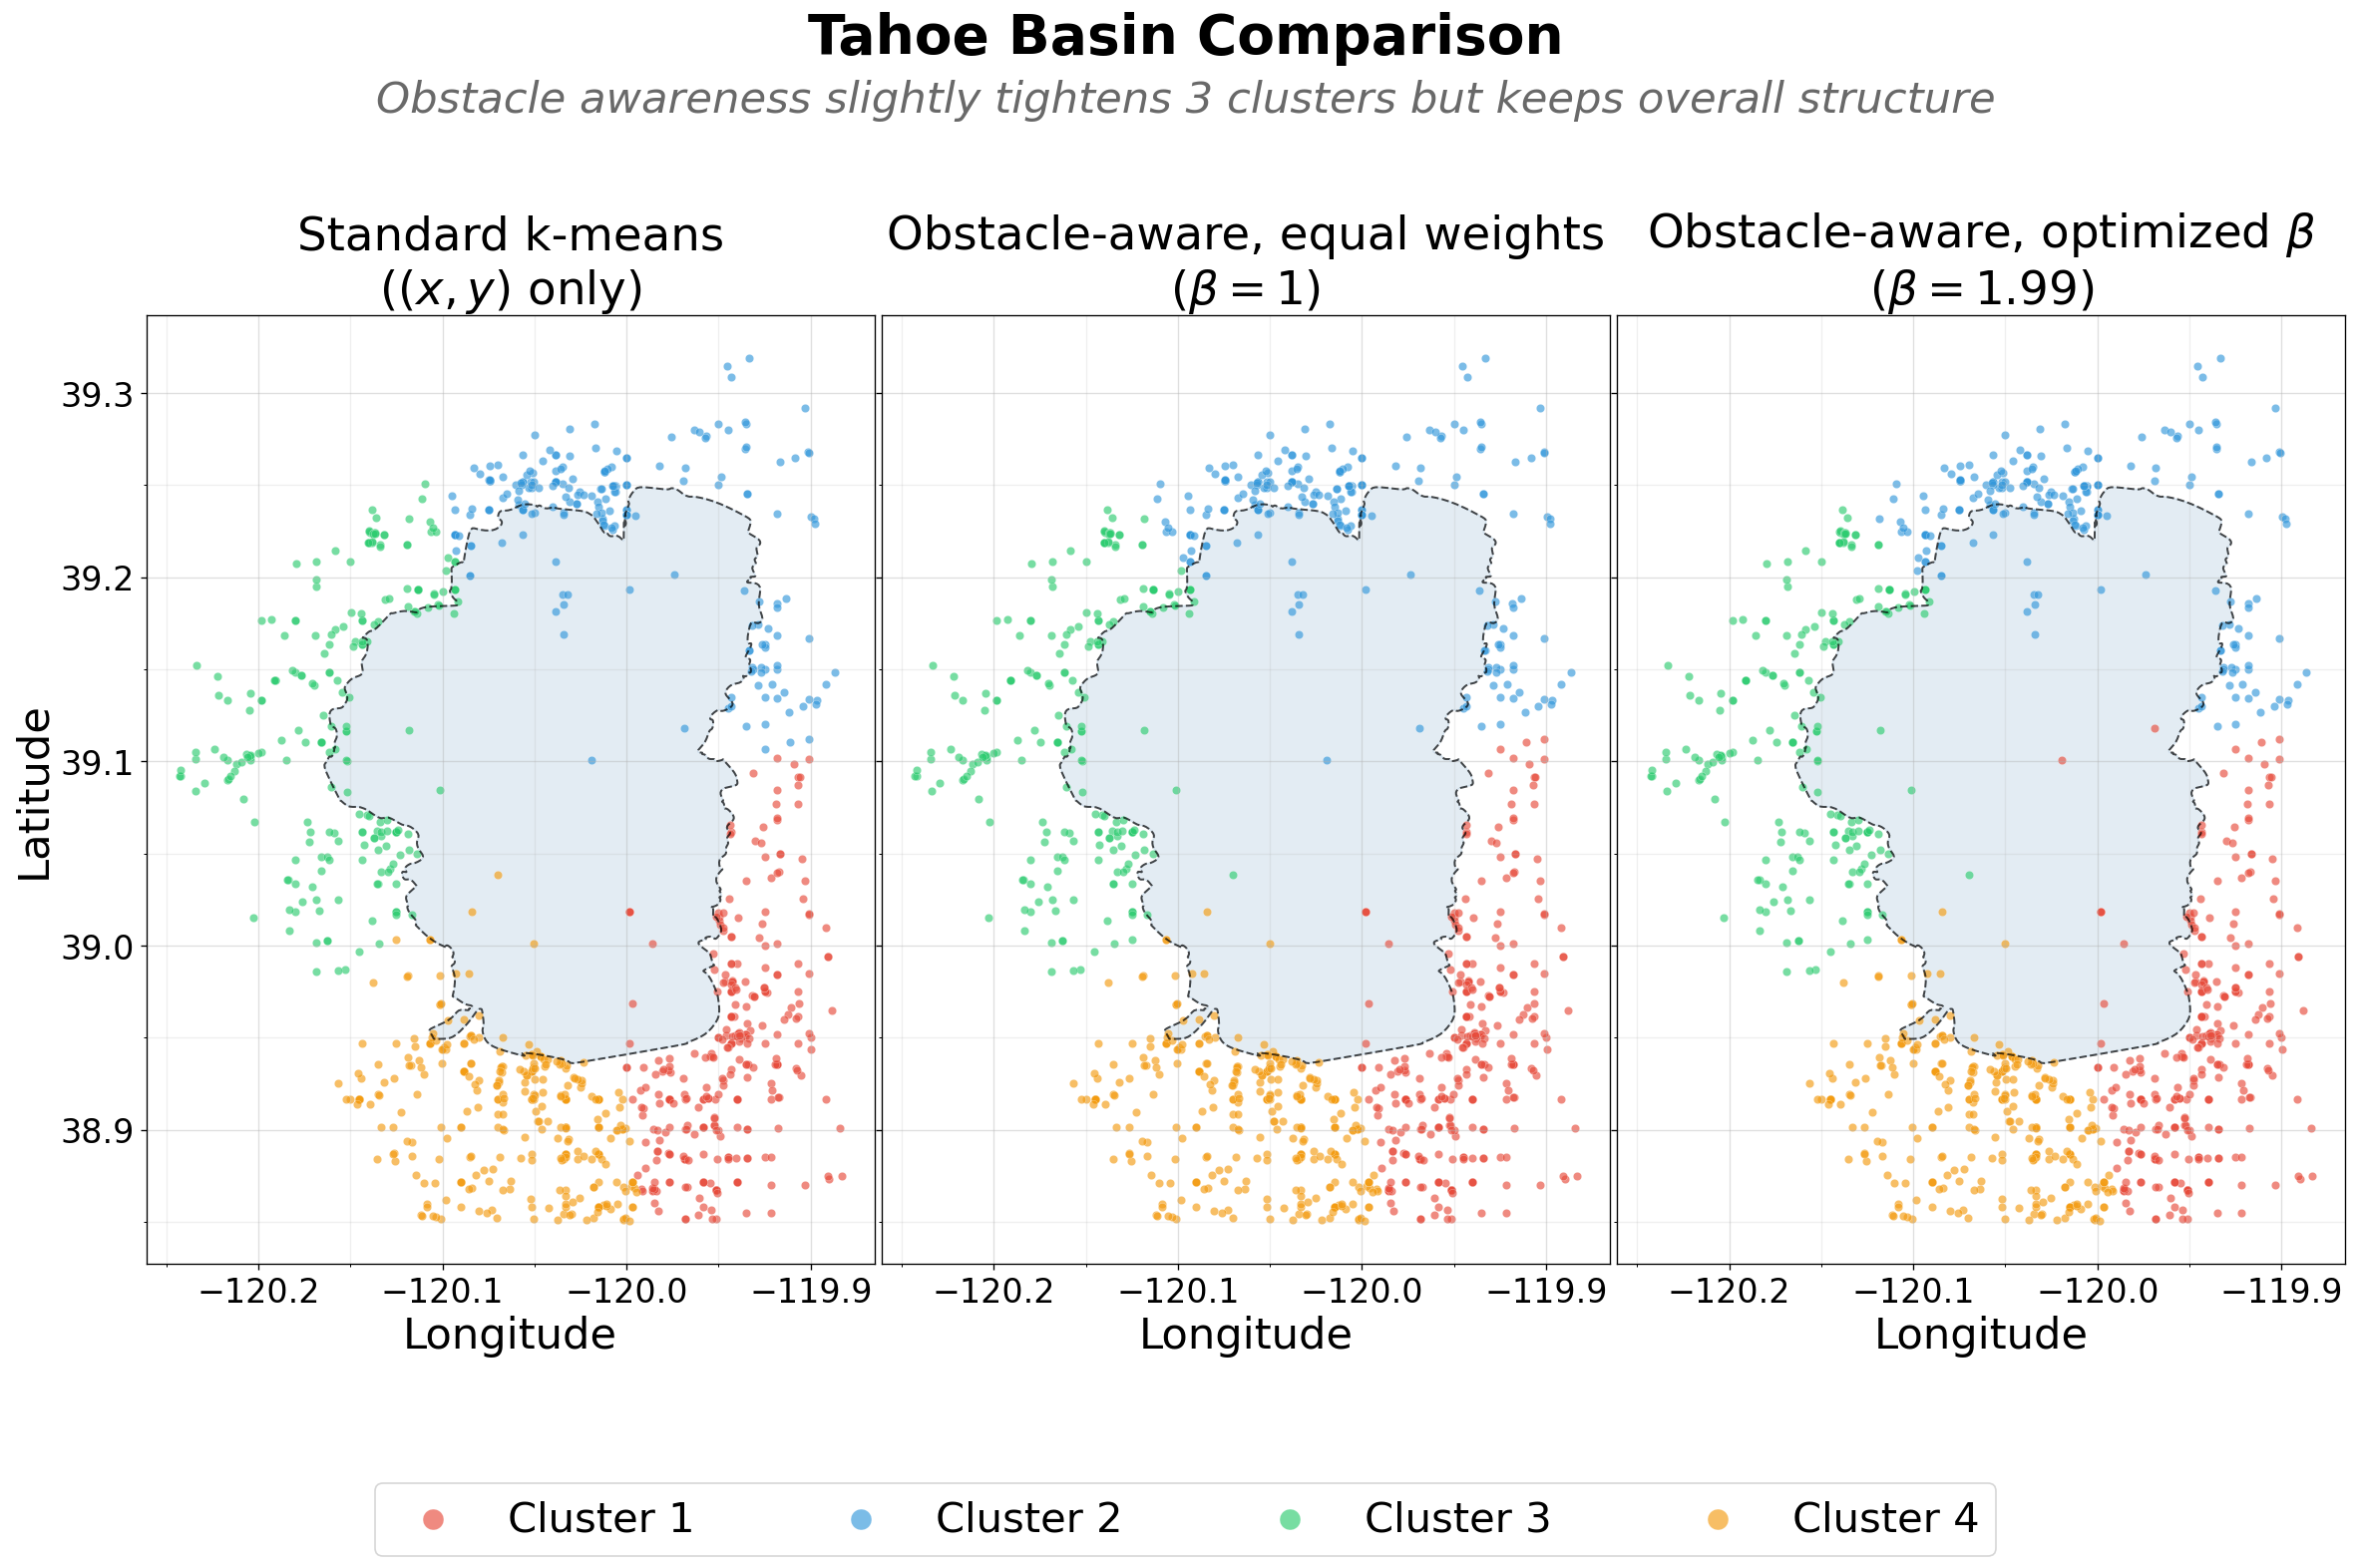

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_basin_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_basin_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1$)'),
    (axes[2], labels_basin_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_basin:.2f}$)'),
]:
    # Boundary
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    # Fires colored by cluster
    for i in range(k):
        mask = labels == i
        ax.scatter(fires['LONGITUDE'].values[mask],
                   fires['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=25, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=28, fontweight='normal')
    ax.set_xlabel('Longitude', fontsize=26)
    ax.set_aspect('equal')

    # Gridlines every 0.05 on both axes; labels only every 0.10 
    ax.xaxis.set_major_locator(MultipleLocator(0.10))   # labeled
    ax.xaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
    ax.yaxis.set_major_locator(MultipleLocator(0.10))   # labeled
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))   # gridline only
    ax.grid(which='major', alpha=0.4)
    ax.grid(which='minor', alpha=0.2)

    ax.tick_params(axis='both', which='major', labelsize=20)

axes[0].set_ylabel('Latitude', fontsize=26)

# Larger legend, pushed further below the panels
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fontsize=25,
           markerscale=2.5, columnspacing=3.0, handletextpad=0.8)

fig.suptitle('Tahoe Basin Comparison', fontsize=33, y=1.05, fontweight='bold')
fig.text(0.5, 0.98,
         'Obstacle awareness slightly tightens 3 clusters but keeps overall structure',
         ha='center', fontsize=26, style='italic', color='dimgray')

# Reserve bottom room for the legend
plt.tight_layout(rect=[0, 0.10, 1, 0.97])
plt.subplots_adjust(wspace=0.01)
plt.show()

### Comparison Statistics

At the basin scale, obstacle awareness gives a modest improvement: equal weights tightens the mean span by 6.6%, and the optimized $\beta$ reaches 8.1%.  The mean cluster span barely moves because the shoreline parameter mostly reshuffles tightness between clusters rather than tightening all of them at once. From equal weights to the optimized $\beta$, cluster 3 tightens sharply (0.27 to 0.19) while cluster 4 loosens (0.19 to 0.25). Tahoe's compact, roughly oval basin doesn't create much ambiguity in $(x,y)$ for $s$ to resolve, so the overall effect stays small.

In [22]:
# Recompute per-cluster spans from the aligned labels so the columns match
# the plot colors and are comparable across methods.
spans_basin_std_aligned = [arc_length_span(fires['s_param'].values[labels_basin_std_aligned == c]) for c in range(k)]
spans_basin_eq_aligned  = [arc_length_span(fires['s_param'].values[labels_basin_eq_aligned == c])  for c in range(k)]
spans_basin_opt_aligned = [arc_length_span(fires['s_param'].values[labels_basin_opt_aligned == c]) for c in range(k)]

basin_methods = [
    ('Standard k-means', spans_basin_std_aligned),
    ('OA, equal weights (β=1)', spans_basin_eq_aligned),
    (f'OA, optimized (β={opt_beta_basin:.2f})', spans_basin_opt_aligned),
]

std_mean_basin = np.mean(spans_basin_std_aligned)

rows = []
for name, spans in basin_methods:
    mean_span = np.mean(spans)
    pct = 100 * (std_mean_basin - mean_span) / std_mean_basin
    row = {'Method': name}
    for c in range(k):
        row[f'Cluster {c+1}'] = spans[c]
    # Display mena span as dimensionless and in km
    row['Mean span'] = f'{mean_span:.4f} ({mean_span * perimeter_km:.1f} km)'
    row['vs standard'] = f'{pct:+.1f}%'
    rows.append(row)

basin_comparison = pd.DataFrame(rows).set_index('Method')

# Format the per-cluster span columns
fmt = {f'Cluster {c+1}': '{:.4f}' for c in range(k)}

print(f'Lake Tahoe basin cluster spans comparison ({len(fires)} fires)')
basin_comparison.style.format(fmt)

Lake Tahoe basin cluster spans comparison (1068 fires)


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean span,vs standard
Method,,,,,,
Standard k-means,0.1977,0.3536,0.2754,0.2331,0.2650 (31.3 km),+0.0%
"OA, equal weights (β=1)",0.1965,0.3361,0.2725,0.1850,0.2475 (29.3 km),+6.6%
"OA, optimized (β=1.99)",0.2256,0.3100,0.2534,0.1850,0.2435 (28.8 km),+8.1%


## 13. Near-Shore Subset

The near-shore subset asks how the method behaves when fires are concentrated near the boundary rather than spread across the whole basin. We filter to fires within 1 km of the shoreline, measuring distance as the straight-line distance from each fire to its boundary projection.

The 1 km threshold keeps the closest 27.7% of fires, a cutoff we reuse in the Lake Mead notebook (where a 5 km threshold keeps a similar fraction), so the two lakes are compared on a similar near-shore definition.

In [23]:
# Each fire's straight-line distance to its boundary projection.
# At latitude ~39 N: 1 deg lat ~= 111 km, 1 deg lon ~= 87 km.
proj = np.array([boundary.evaluate(t) for t in fires['t_param'].values])
lon_diff = fires['LONGITUDE'].values - proj[:, 0]
lat_diff = fires['LATITUDE'].values - proj[:, 1]
fires['dist_to_lake_km'] = np.sqrt((lon_diff * 87)**2 + (lat_diff * 111)**2)

# Distance distribution
print('Fire distance distribution (km from Lake Tahoe shore):')
for thr in [1, 2, 5, 10]:
    n = (fires['dist_to_lake_km'] < thr).sum()
    print(f'  Within {thr:2d} km: {n:4d} fires ({100*n/len(fires):.1f}%)')
print(f'  Total: {len(fires)} fires')

# Filter to fires within 1 km of shore
threshold_km = 1
near_mask = fires['dist_to_lake_km'].values < threshold_km
n_near = int(near_mask.sum())

print(f'\nNear-shore subset: {n_near} fires within {threshold_km} km of shore')

# Subset arrays
X_near = X[near_mask]
t_near = fires['t_param'].values[near_mask]
s_near = fires['s_param'].values[near_mask]
fires_near = fires[near_mask].copy().reset_index(drop=True)

Fire distance distribution (km from Lake Tahoe shore):
  Within  1 km:  296 fires (27.7%)
  Within  2 km:  468 fires (43.8%)
  Within  5 km:  820 fires (76.8%)
  Within 10 km: 1050 fires (98.3%)
  Total: 1068 fires

Near-shore subset: 296 fires within 1 km of shore


## 14. Near-Shore Clustering: Three Methods

The same three methods as the basin, applied to the near-shore subset.

### 14.1 Standard k-means (Near-Shore)

In [24]:
kmeans_near = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_near_std = kmeans_near.fit_predict(X_near[:, :2])

spans_near_std = [arc_length_span(s_near[labels_near_std == c]) for c in range(k)]

print(f'Standard k-means on near-shore subset:')
print(f'  Converged in {kmeans_near.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_std == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_std):.4f}')
print(f'\nSee clusters plotted in Section 15')

Standard k-means on near-shore subset:
  Converged in 5 iterations
  Cluster 1: 93 fires
  Cluster 2: 71 fires
  Cluster 3: 51 fires
  Cluster 4: 81 fires
  Mean arc-length span: 0.2246

See clusters plotted in Section 15


### 14.2 Obstacle-Aware k-means at Equal Weights (Near-Shore)

In [25]:
model_near_eq = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=1.0, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_eq.fit(X_near[:, :3], t_data=t_near)
labels_near_eq = model_near_eq.labels_

spans_near_eq = [arc_length_span(s_near[labels_near_eq == c]) for c in range(k)]

print(f'OA equal weights on near-shore subset:')
print(f'  Converged in {model_near_eq.n_iter_} iterations')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_eq == i)} fires')
print(f'  Mean arc-length span: {np.mean(spans_near_eq):.4f}')
print(f'\nSee clusters plotted in Section 15')

OA equal weights on near-shore subset:
  Converged in 9 iterations
  Cluster 1: 94 fires
  Cluster 2: 51 fires
  Cluster 3: 71 fires
  Cluster 4: 80 fires
  Mean arc-length span: 0.2261

See clusters plotted in Section 15


### 14.3 Obstacle-Aware k-means at Optimized $\beta$ (Near-Shore)

Same workflow as the basin: sweep $\beta$ recording $J$ and the mean span at each, apply the selection rule (stable low-$J$ region, smallest span, every cluster above the size floor), then plot the result to see where the chosen $\beta$ lands.

In [26]:
def compute_tahoe_nearshore_beta_sweep():
    """Sweep beta, recording J (within-cluster distortion) and mean span at each.

    One model fit per beta gives both metrics, so J and span always come from
    the same clustering rather than two separate fits.
    """
    print('Computing Tahoe near-shore beta sweep (J and span)...')
    n_grid = 30
    beta_vals = np.linspace(0.05, 2.0, n_grid)
    J_vals = np.zeros(n_grid)
    span_vals = np.zeros(n_grid)

    for i, b in enumerate(beta_vals):
        model_b = ObstacleKMeans(
            k=k, boundary=boundary,
            alpha=1.0, beta=b, gamma=0.0,
            random_state=42, n_attr=0
        )
        model_b.fit(X_near[:, :3], t_data=t_near)

        # J is the model's mean within-cluster distortion (rho_bar), with no
        # beta applied, so J is comparable across beta.
        J_vals[i] = model_b.rho_bar_

        # Mean arc-length span from the same fit
        spans_b = [arc_length_span(s_near[model_b.labels_ == c]) for c in range(k)]
        span_vals[i] = np.mean(spans_b)

    return beta_vals, J_vals, span_vals


beta_grid_near, J_vals_near, spans_by_beta_near = cached_or_run(
    cache_dir / 'tahoe_nearshore_beta_sweep.pkl',
    compute_tahoe_nearshore_beta_sweep,
)

# Where J is lowest on the grid, for reference (not necessarily our final pick)
i_min_near = J_vals_near.argmin()
j_min_beta_near = beta_grid_near[i_min_near]
j_min_J_near = J_vals_near[i_min_near]

print(f'J-minimum on grid: beta = {j_min_beta_near:.4f}, J = {j_min_J_near:.4f}')

Loading cached: tahoe_nearshore_beta_sweep.pkl
J-minimum on grid: beta = 0.9914, J = 0.0194


### Selecting $\beta$ and Refitting

We apply the same selection as the basin run. The plot shows $J$ sits flat and low across the whole small-$\beta$ region (up to about $\beta = 1.1$) and jumps up beyond it, and the span gives no reason to prefer any particular $\beta$ in that flat region.

The selection lands at $\beta = 0.86$, in the stable low-$J$ region, where the obstacle-aware clustering comes out essentially identical to standard k-means: the same mean span, no improvement. It seems that near the shore, the arc-length parameter has nothing to add.

In [27]:
# Same filters as basin-wide: ensure stable low-J region, smallest span,
# every cluster above the size floor. Checks candidates in span order, stops at
# the first that passes. 
J_tol = 0.001
min_cluster_size = 10

J_best = J_vals_near.min()
low_J = J_vals_near <= J_best + J_tol

left_ok = np.zeros_like(low_J)
right_ok = np.zeros_like(low_J)
left_ok[1:] = low_J[:-1]
right_ok[:-1] = low_J[1:]
stable = low_J & (left_ok | right_ok)

candidates = np.where(stable)[0]
candidates = candidates[np.argsort(spans_by_beta_near[candidates])]

opt_beta_near = None
for idx in candidates:
    b = beta_grid_near[idx]
    m = ObstacleKMeans(k=k, boundary=boundary, alpha=1.0, beta=b, gamma=0.0,
                       random_state=42, n_attr=0)
    m.fit(X_near[:, :3], t_data=t_near)
    sizes = [np.sum(m.labels_ == c) for c in range(k)]
    if min(sizes) > min_cluster_size:
        opt_beta_near = b
        i_sel = idx
        break

if opt_beta_near is None:
    raise ValueError('No stable low-J beta satisfies the size floor; loosen J_tol.')

print(f'Selected beta = {opt_beta_near:.4f} '
      f'(J = {J_vals_near[i_sel]:.4f}, span = {spans_by_beta_near[i_sel]:.4f})')

Selected beta = 0.8569 (J = 0.0194, span = 0.2246)


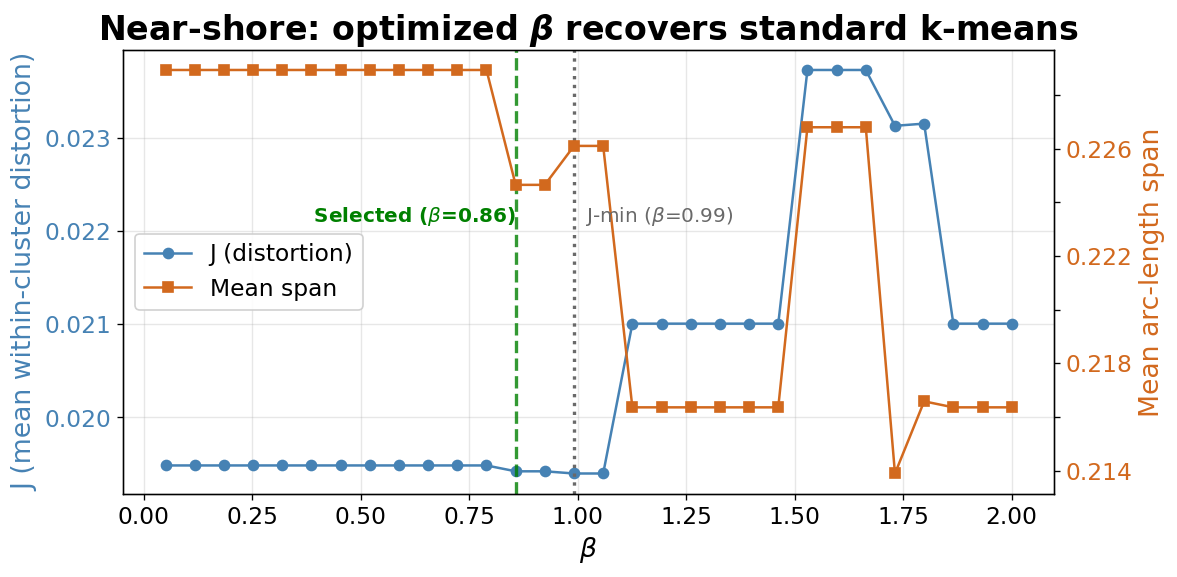

In [28]:
# Plot the J / span over the 30 beta grid points
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: objective J (within-cluster distortion)
color_J = 'steelblue'
ax1.plot(beta_grid_near, J_vals_near, 'o-', color=color_J, label='J (distortion)')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('J (mean within-cluster distortion)', color=color_J)
ax1.tick_params(axis='y', labelcolor=color_J)

# Right axis: mean arc-length span
ax2 = ax1.twinx()
color_span = 'chocolate'
ax2.plot(beta_grid_near, spans_by_beta_near, 's-', color=color_span,
         label='Mean span')
ax2.set_ylabel('Mean arc-length span', color=color_span)
ax2.tick_params(axis='y', labelcolor=color_span)

# Gridlines every 0.002 on span axis, but label only every other one
# (so labels appear at 0.214, 0.218, 0.222, 0.226)
ax2.yaxis.set_major_locator(MultipleLocator(0.002))
def label_every_other_span_near(x, pos):
    return f'{x:.3f}' if round(x * 1000) % 4 == 2 else ''
ax2.yaxis.set_major_formatter(FuncFormatter(label_every_other_span_near))

# Mark the J-minimum (reference, not selected)
ax1.axvline(j_min_beta_near, color='dimgray', linestyle=':', alpha=1.0, linewidth=2)
ax2.text(j_min_beta_near, 0.65,
         rf'  J-min ($\beta$={j_min_beta_near:.2f})',
         color='dimgray', fontsize=12, va='top', ha='left',
         transform=ax2.get_xaxis_transform())

# Mark the selected beta (lower span among stable low-J region)
ax1.axvline(opt_beta_near, color='green', linestyle='--', alpha=0.8, linewidth=2)
ax2.text(opt_beta_near, 0.65,
         rf'  Selected ($\beta$={opt_beta_near:.2f})',
         color='green', fontsize=12, va='top', ha='right',
         fontweight='bold',
         transform=ax2.get_xaxis_transform())

ax1.set_title(r'Near-shore: optimized $\boldsymbol{\beta}$ recovers standard k-means')
ax1.grid(True, alpha=0.3)

# Combine legends from both axes (just J and span, no vertical-line clutter)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax2.legend(lines1 + lines2, labels1 + labels2, loc='center left')
leg.set_zorder(10)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

In [29]:
# Refit at the selected beta
model_near_opt = ObstacleKMeans(
    k=k, boundary=boundary,
    alpha=1.0, beta=opt_beta_near, gamma=0.0,
    random_state=42, n_attr=0
)
model_near_opt.fit(X_near[:, :3], t_data=t_near)
labels_near_opt = model_near_opt.labels_

spans_near_opt = [arc_length_span(s_near[labels_near_opt == c]) for c in range(k)]

print(f'Optimized beta: {opt_beta_near:.4f}')
print(f'(J-minimum on grid was at beta = {j_min_beta_near:.4f})')
print('\nCluster sizes:')
for i in range(k):
    print(f'  Cluster {i+1}: {np.sum(labels_near_opt == i)} fires')
print(f'\nMean arc-length span: {np.mean(spans_near_opt):.4f}')

Optimized beta: 0.8569
(J-minimum on grid was at beta = 0.9914)

Cluster sizes:
  Cluster 1: 93 fires
  Cluster 2: 51 fires
  Cluster 3: 71 fires
  Cluster 4: 81 fires

Mean arc-length span: 0.2246


## 15. Near-Shore Clustering Method Comparison
We compare the results of our three clustering methods on the near-shore subset.

### Align Cluster Labels

The near-shore clusters are aligned to the basin's optimized clustering (restricted to the near-shore fires) so colors mean the same geographic position across both scales: "Cluster 1" is in the same region whether you're looking at the basin or near-shore results.

In [30]:
# Align all three near-shore clusterings to the basin's optimized labeling
ref_labels_near = labels_basin_opt_aligned[near_mask]

std_to_basin_near = map_labels_to_reference(labels_near_std, ref_labels_near, k)
labels_near_std_aligned = np.array([std_to_basin_near[lbl] for lbl in labels_near_std])

eq_to_basin_near = map_labels_to_reference(labels_near_eq, ref_labels_near, k)
labels_near_eq_aligned = np.array([eq_to_basin_near[lbl] for lbl in labels_near_eq])

opt_to_basin_near = map_labels_to_reference(labels_near_opt, ref_labels_near, k)
labels_near_opt_aligned = np.array([opt_to_basin_near[lbl] for lbl in labels_near_opt])

print('Near-shore labels aligned to basin reference for cross-scale color consistency.')

Near-shore labels aligned to basin reference for cross-scale color consistency.


### Visual Comparison

The three panels are almost indistinguishable: the same four shoreline groups in the same places. With the fires already wrapped tightly around the shore, adding $s$ doesn't change much.

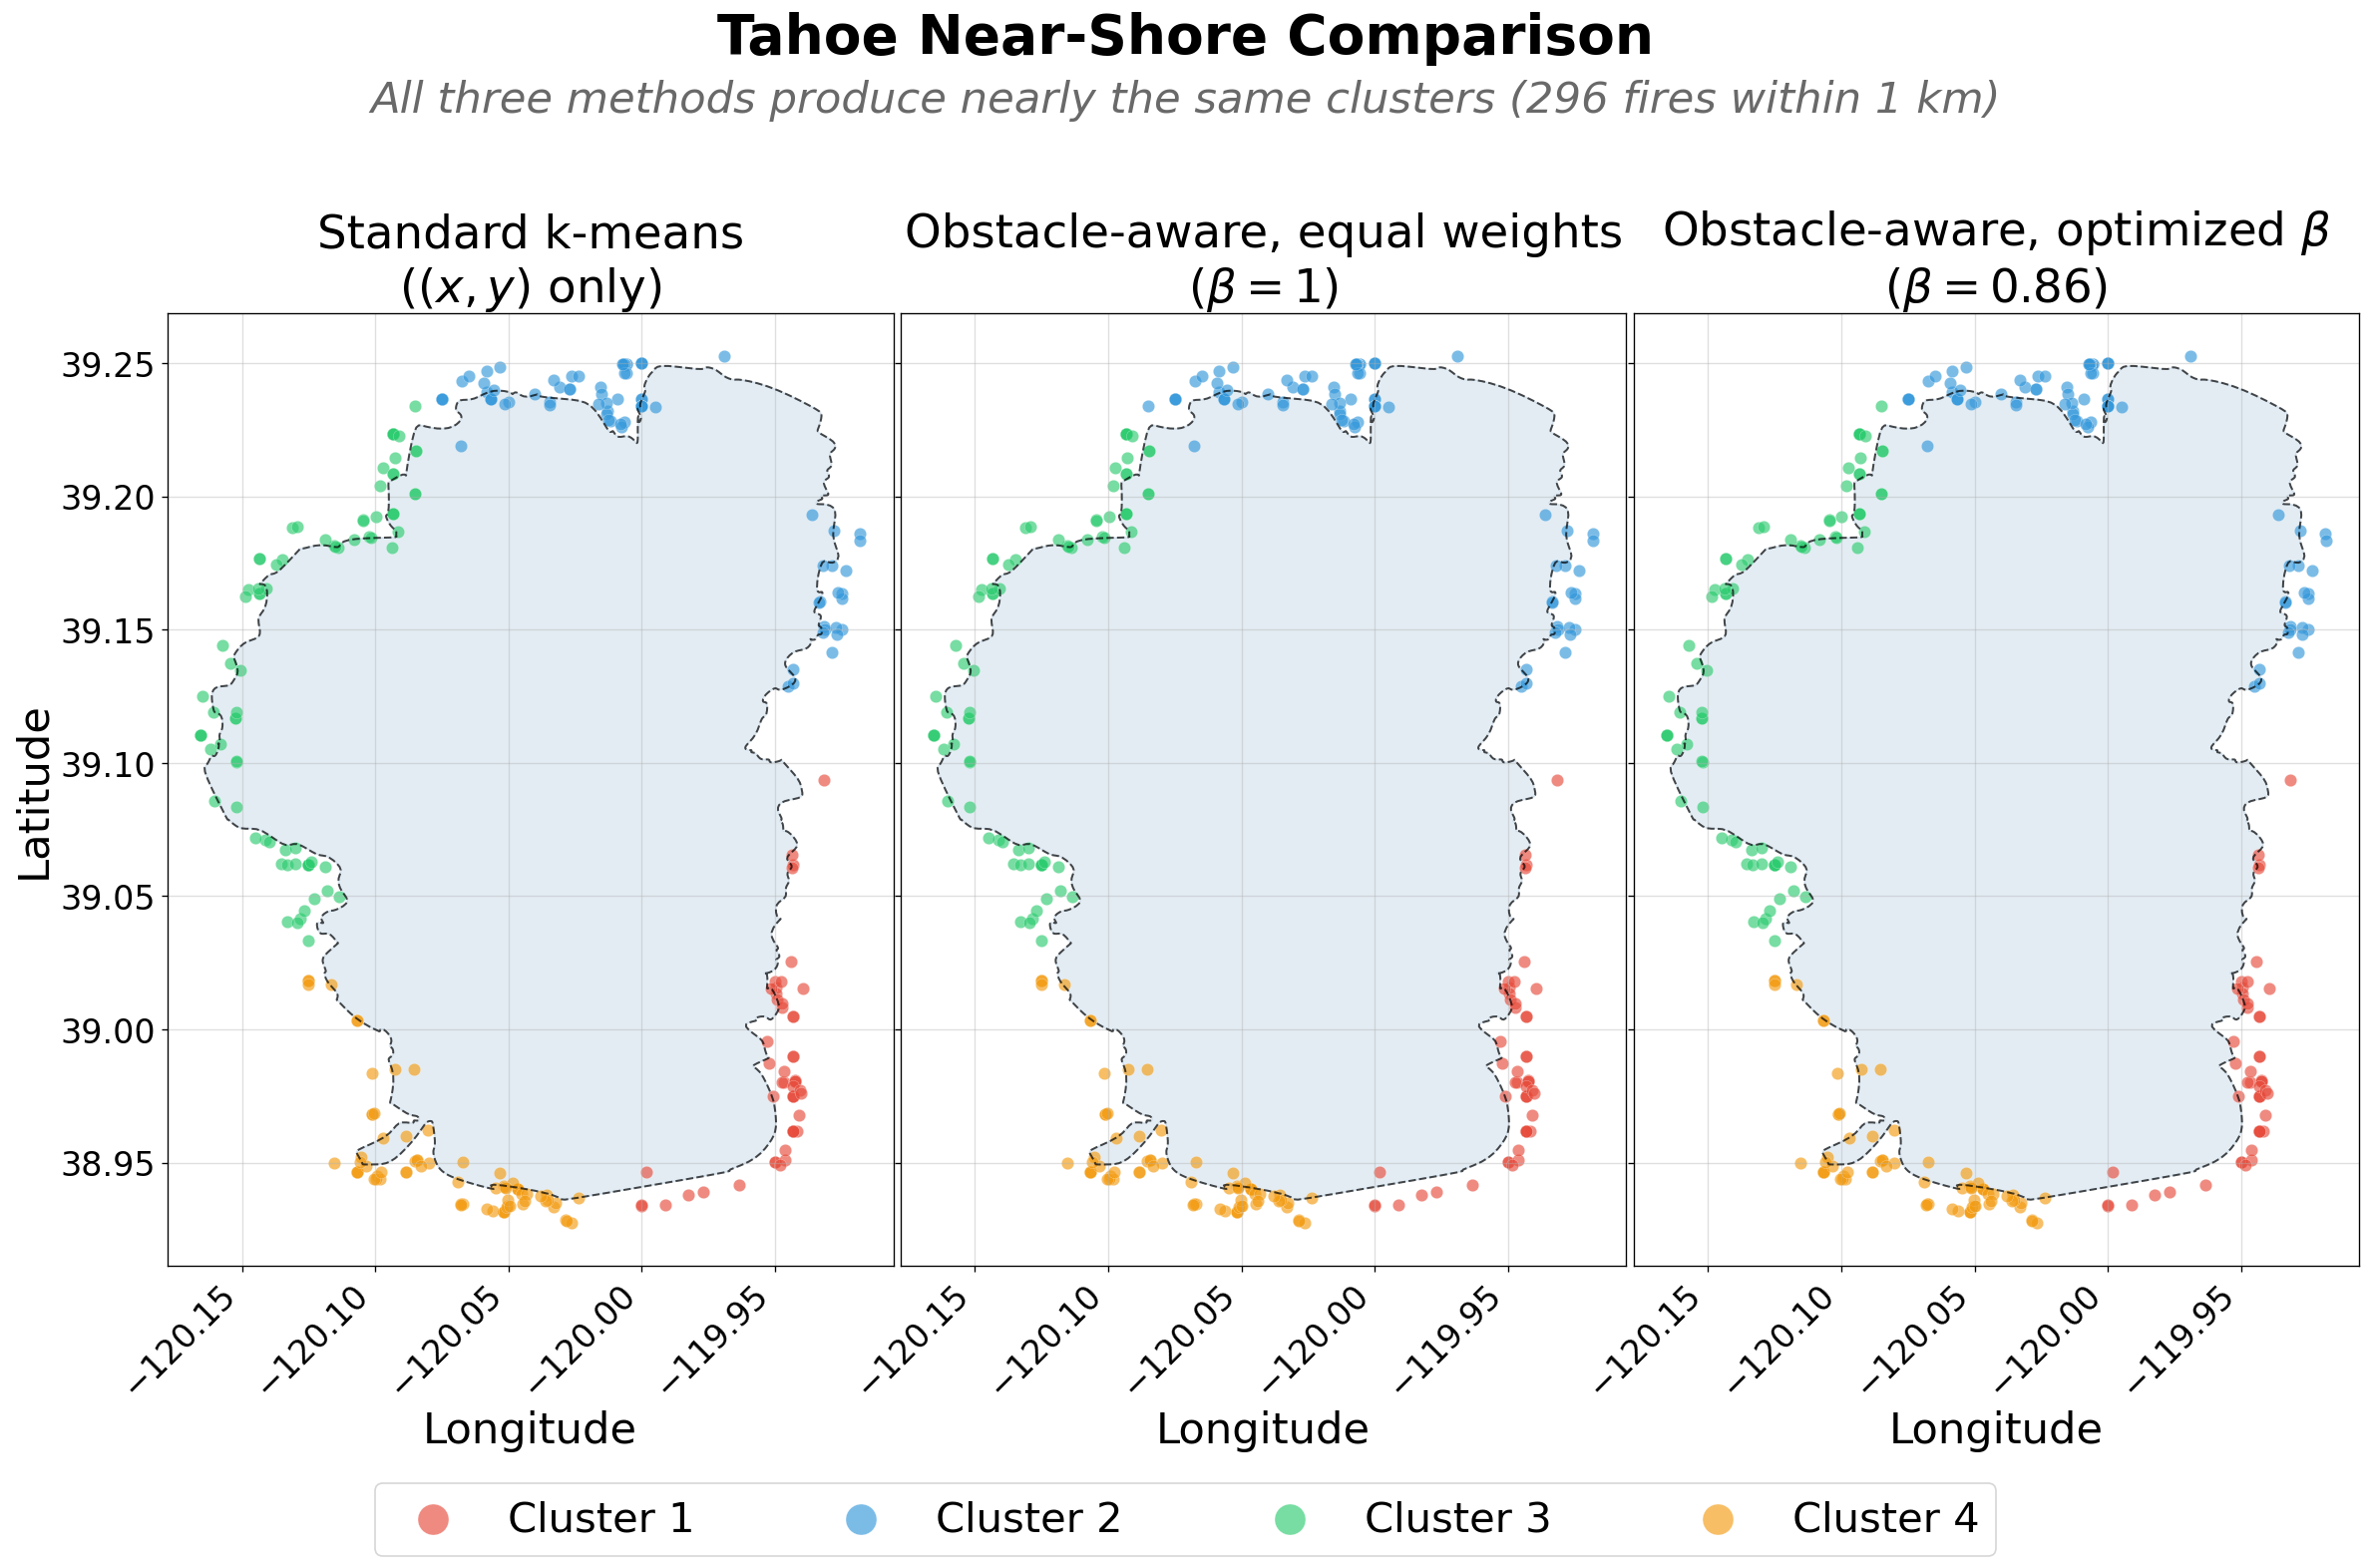

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 12), sharex=True, sharey=True)

for ax, labels, title in [
    (axes[0], labels_near_std_aligned, 'Standard k-means\n($(x, y)$ only)'),
    (axes[1], labels_near_eq_aligned,
     r'Obstacle-aware, equal weights' + '\n' + r'($\beta = 1$)'),
    (axes[2], labels_near_opt_aligned,
     r'Obstacle-aware, optimized $\beta$' + '\n' +
     rf'($\beta = {opt_beta_near:.2f}$)'),
]:
    # Boundary
    ax.plot(spline_pts[:, 0], spline_pts[:, 1], color='black', linestyle='--',
            linewidth=1.2, alpha=0.7)
    ax.fill(spline_pts[:, 0], spline_pts[:, 1], alpha=0.15, color='steelblue')

    # Fires colored by cluster
    for i in range(k):
        mask = labels == i
        ax.scatter(fires_near['LONGITUDE'].values[mask],
                   fires_near['LATITUDE'].values[mask],
                   c=CLUSTER_COLORS[i], s=55, alpha=0.65,
                   label=f'Cluster {i+1}', edgecolors='white', linewidth=0.2)

    ax.set_title(title, fontsize=28, fontweight='normal')
    ax.set_xlabel('Longitude', fontsize=26)
    ax.set_aspect('equal')

    # Gridlines and labels every 0.05 on both axes
    ax.xaxis.set_major_locator(MultipleLocator(0.05))
    ax.yaxis.set_major_locator(MultipleLocator(0.05))
    ax.grid(which='major', alpha=0.4)

    ax.tick_params(axis='both', which='major', labelsize=20)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

axes[0].set_ylabel('Latitude', fontsize=26)

# Larger legend, pushed further below the panels
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc='lower center', ncol=k,
           bbox_to_anchor=(0.5, -0.04), frameon=True, fontsize=25,
           markerscale=2.5, columnspacing=3.0, handletextpad=0.8)

fig.suptitle(
    f'Tahoe Near-Shore Comparison',
    fontsize=33, y=1.05, fontweight='bold'
)
fig.text(0.5, 0.98,
         f'All three methods produce nearly the same clusters '
         f'({n_near} fires within {threshold_km} km)',
         ha='center', fontsize=26, style='italic', color='dimgray')

# Reserve bottom room for the legend
plt.tight_layout(rect=[0, 0.10, 1, 0.97])
plt.subplots_adjust(wspace=0.01)
plt.show()

### Comparison Statistics

Near the shore, the obstacle parameter brings no improvement. Equal weights lands slightly worse than standard k-means (a 0.6% increase in span), and the optimized $\beta = 0.86$ recovers the standard result exactly, with the same per-cluster spans and the same mean. No weighting of $\beta$ does better than plain k-means here.

In [32]:
# Recompute per-cluster spans from the aligned labels (aligned to the basin
# optimized reference) so the columns match the plot colors.
spans_near_std_aligned = [arc_length_span(s_near[labels_near_std_aligned == c]) for c in range(k)]
spans_near_eq_aligned  = [arc_length_span(s_near[labels_near_eq_aligned == c])  for c in range(k)]
spans_near_opt_aligned = [arc_length_span(s_near[labels_near_opt_aligned == c]) for c in range(k)]

near_methods = [
    ('Standard k-means', spans_near_std_aligned),
    ('OA, equal weights (β=1)', spans_near_eq_aligned),
    (f'OA, optimized (β={opt_beta_near:.2f})', spans_near_opt_aligned),
]

std_mean_near = np.mean(spans_near_std_aligned)

rows = []
for name, spans in near_methods:
    mean_span = np.mean(spans)
    pct = 100 * (std_mean_near - mean_span) / std_mean_near
    row = {'Method': name}
    for c in range(k):
        row[f'Cluster {c+1}'] = spans[c]
    # Display mean span as dimensionless and in km
    row['Mean span'] = f'{mean_span:.4f} ({mean_span * perimeter_km:.1f} km)'
    row['vs standard'] = f'{pct:+.1f}%'
    rows.append(row)

near_comparison = pd.DataFrame(rows).set_index('Method')

# Format the per-cluster span columns
fmt = {f'Cluster {c+1}': '{:.4f}' for c in range(k)}

print(f'Lake Tahoe near-shore cluster spans comparison ({n_near} fires within {threshold_km} km of shore)')
near_comparison.style.format(fmt)


Lake Tahoe near-shore cluster spans comparison (296 fires within 1 km of shore)


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Mean span,vs standard
Method,,,,,,
Standard k-means,0.1937,0.2755,0.2475,0.1819,0.2246 (26.6 km),+0.0%
"OA, equal weights (β=1)",0.1937,0.2862,0.2426,0.1819,0.2261 (26.7 km),-0.6%
"OA, optimized (β=0.86)",0.1937,0.2755,0.2475,0.1819,0.2246 (26.6 km),+0.0%


## 16. Basin vs. Near-Shore Summary

Putting the two scales side by side, the obstacle parameter helps at the basin scale and not near the shore. Across the full basin, the optimized $\beta$ tightens the mean span by 8.1% over standard k-means; within 1 km of the shoreline, the optimized clustering recovers standard k-means exactly, with no improvement at all.

One possible reason for this is how much independent information $s$ carries at each scale. Near the shore, the fires form a thin ring, and a fire's position around that ring is almost entirely determined by its $(x, y)$ location, so $s$ is almost redundant with the coordinates. Across the full basin, fires sit at varying distances from the lake, and a distant fire's $(x, y)$ position doesn't totally determine which stretch of shoreline it belongs to. So $s$ carries information the coordinates don't, and the clustering has something to gain from it.

You might expect the obstacle parameter to matter most right next to the obstacle, but here the opposite is true: $s$ only contributes to tighter clusters where fires are spread out enough that distance along the shore and straight-line distance disagree, which is the basin, not the shoreline.

In [33]:
# Combined basin + near-shore summary. Pulls means already computed.
std_mean_basin = np.mean(spans_basin_std)
std_mean_near = np.mean(spans_near_std)

summary_rows = [
    # scale,        method,                                  n_fires,    spans
    ('Basin',      'Standard k-means',                       len(fires), spans_basin_std),
    ('Basin',      'OA, equal weights (β=1)',                len(fires), spans_basin_eq),
    ('Basin',      f'OA, optimized (β={opt_beta_basin:.2f})', len(fires), spans_basin_opt),
    ('Near-shore', 'Standard k-means',                       n_near,     spans_near_std),
    ('Near-shore', 'OA, equal weights (β=1)',                n_near,     spans_near_eq),
    ('Near-shore', f'OA, optimized (β={opt_beta_near:.2f})',  n_near,     spans_near_opt),
]

rows = []
for scale, method, n_fires, spans in summary_rows:
    mean_span = np.mean(spans)
    # Improvement is measured against that scale's own standard k-means baseline.
    std_mean = std_mean_basin if scale == 'Basin' else std_mean_near
    pct = 100 * (std_mean - mean_span) / std_mean
    rows.append({
        'Scale': scale,
        'Method': method,
        'Fires': n_fires,
        'Mean span (km)': mean_span * perimeter_km,
        'Span improvement': pct,
    })

summary = pd.DataFrame(rows).set_index(['Scale', 'Method'])

fmt = {
    'Fires': '{:d}',
    'Mean span (km)': '{:.1f}',
    'Span improvement': '{:+.1f}%',
}

print('Lake Tahoe: basin vs. near-shore summary')
summary.style.format(fmt)

Lake Tahoe: basin vs. near-shore summary


## 17. Cluster Attribute Composition (Basin)

The clustering used only location, never fire size or cause. But since the basin is where the obstacle parameter actually tightened the clusters, it's worth asking whether those geographic clusters happen to differ in their fire attributes too. We show the attribute breakdown for both the standard and optimized clusterings, then test whether any of the differences are statistically meaningful.

The tables below break down each cluster's size, the split between human-caused and natural fires, and the typical and average fire size, first for standard k-means and then for the optimized obstacle-aware clustering.

In [34]:
def cluster_composition(labels, fires_subset):
    """Per-cluster size, cause split, and fire-size summary for a labeling.
    Built from aligned labels, so cluster numbers match the plot colors."""
    rows = []
    for c in range(k):
        mask = labels == c
        sizes = fires_subset['FIRE_SIZE'].values[mask]
        human = fires_subset['cause_binary'].values[mask]   # 1 = human, 0 = natural
        rows.append({
            'Cluster': c + 1,
            'Fires': int(mask.sum()),
            '% human': 100 * human.mean(),
            '% natural': 100 * (1 - human.mean()),
            'Median size (ac)': np.median(sizes),
            'Mean size (ac)': sizes.mean(),
        })
    return pd.DataFrame(rows).set_index('Cluster')


fmt = {
    'Fires': '{:d}',
    '% human': '{:.1f}',
    '% natural': '{:.1f}',
    'Median size (ac)': '{:.2f}',
    'Mean size (ac)': '{:.2f}',
}

# Standard k-means composition table
print('Standard k-means:')
display(cluster_composition(labels_basin_std_aligned, fires).style.format(fmt))

# Optimized obstacle-aware composition table
print(f'\nObstacle-aware, optimized (β={opt_beta_basin:.2f}):')
display(cluster_composition(labels_basin_opt_aligned, fires).style.format(fmt))

Standard k-means:


,Fires,% human,% natural,Median size (ac),Mean size (ac)
Cluster,,,,,
1,305,76.1,23.9,0.10,2.52
2,230,80.0,20.0,0.10,28.41
3,223,80.3,19.7,0.10,1.57
4,310,86.8,13.2,0.10,11.09



Obstacle-aware, optimized (β=1.99):


,Fires,% human,% natural,Median size (ac),Mean size (ac)
Cluster,,,,,
1,307,75.9,24.1,0.10,2.51
2,236,80.9,19.1,0.10,27.91
3,214,79.4,20.6,0.10,1.39
4,311,86.8,13.2,0.10,11.05


### Testing for Significant Differences Among Clusters

The composition table shows some surface-level variation (mean fire size in particular varies widely between clusters), but raw differences in a sample can appear just by chance. To check whether any differences are real, we use the Kruskal-Wallis test, a rank-based test that asks whether the clusters' distributions of an attribute differ more than we'd expect by chance. It's non-parametric, so it doesn't assume the data is normally distributed, which matters here since fire sizes are extremely skewed. Where Kruskal-Wallis flags a significant overall difference, we follow up with Dunn's test to see which specific cluster pairs differ, applying a Bonferroni correction since we're making several pairwise comparisons at once.

We report the fraction of cluster pairs that differ significantly in fire size, and in cause, and we run it for both standard k-means and the optimized obstacle-aware clustering to see whether obstacle awareness changes the attribute structure at all.

Both clusterings have the same results: no cluster pair differs significantly in fire size, and only one of six differs in cause (a fraction of 0.08 either way). So at least at $k = 4$, where a fire is located doesn't line up with how big it gets or how it starts, and the obstacle parameter doesn't change that. The wide spread in mean fire size from the table is driven by a few large fires.

In [35]:
# Attributes live in columns 3 (fire size, log-scaled) and 4 (cause binary).
attr_indices = [3, 4]
attr_labels = {3: 'Fire size', 4: 'Cause'}

# Fraction of significant pairwise cluster differences, per attribute, per method.
def attr_fractions(labels, method_name):
    sigma, details = attribute_separation(X, labels, k, attr_indices)
    print(f'{method_name}:')
    n_pairs = k * (k - 1) // 2
    for idx in attr_indices:
        sig_pairs = details[idx]['pairwise_significant']
        print(f'  {attr_labels[idx]:10s}: {len(sig_pairs)}/{n_pairs} '
              f'pairs differ significantly')
    print(f'  Overall significant fraction: {sigma:.2f}\n')
    return sigma

_ = attr_fractions(labels_basin_std_aligned, 'Standard k-means')
_ = attr_fractions(labels_basin_opt_aligned, f'Obstacle-aware, optimized (β={opt_beta_basin:.2f})')

Standard k-means:
  Fire size : 0/6 pairs differ significantly
  Cause     : 1/6 pairs differ significantly
  Overall significant fraction: 0.08

Obstacle-aware, optimized (β=1.99):
  Fire size : 0/6 pairs differ significantly
  Cause     : 1/6 pairs differ significantly
  Overall significant fraction: 0.08



## 18. Saving Cluster Assignments

We save the cleaned dataset with cluster labels from all three methods for outside use.

In [36]:
# Write all cluster labels to the fires DataFrame 
fires['cluster_basin_std'] = labels_basin_std_aligned
fires['cluster_basin_eq']  = labels_basin_eq_aligned
fires['cluster_basin_opt'] = labels_basin_opt_aligned

# Near-shore labels: NaN for fires outside the subset
fires['cluster_near_std'] = np.nan
fires['cluster_near_eq']  = np.nan
fires['cluster_near_opt'] = np.nan
fires.loc[near_mask, 'cluster_near_std'] = labels_near_std_aligned
fires.loc[near_mask, 'cluster_near_eq']  = labels_near_eq_aligned
fires.loc[near_mask, 'cluster_near_opt'] = labels_near_opt_aligned

# Save to the project's data/processed folder
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

fires_path = processed_dir / 'tahoe_fires_clustered.csv'  
fires.to_csv(fires_path, index=False)

print(f'Saved {len(fires)} clustered fires to:')
print(f'  {fires_path}')

Saved 1068 clustered fires to:
  ..\data\processed\tahoe_fires_clustered.csv


## 19. Summary

- **Basin scale**: obstacle-aware k-means tightens the mean arc-length span by 8.1% over standard k-means. $J$ doesn't single out one $\beta$ (it's about equally low across a wide range), so we picked $\beta = 1.99$ from within that range as the value that gave the tightest span.
- **Near-shore scale (within 1 km)**: the obstacle parameter brings no improvement. $J$ prefers small $\beta$, the optimized value lands at essentially equal weights, and span barely moves (0.6% the wrong way). Within 1 km of shore, $s$ is nearly redundant with the coordinates, so there's little for it to add.

So $s$ contributes to cluster compactness in the basin and not right along the shore, which is the opposite of what you might guess for a parameter built around the boundary. This may be because the basin covers a wider area with more variability in fire coordinates,  so $s$ is able to contribute useful information about distance around the shoreline. While close to shore, $(x,y)$ already corresponds to a particular region along the shore, so $s$ is redundant.

We also checked whether the geographic clusters happen to differ in fire size or cause. They mostly don't, at least at $k = 4$, and standard and obstacle-aware clusterings look about the same on this.

Tahoe's compact, roughly oval shape matters here too. Notebook 03 runs the same method on Lake Mead, a long, narrow lake where the geometry lets $s$ carry more information.